# Comprehensive Dataset Analysis
This notebook provides a step-by-step analysis of the train, validation, and test datasets for temporal graph neural networks. We will explore adjacency matrix properties, node features, homophily, up ratios, and more.

In [76]:
# Import required libraries
from dataset_analyzer import MarketAnalyzer
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets
We load the train, validation, and test datasets using the MarketAnalyzer class.

In [77]:
MARKET = 'SSE'
NORMALIZATION = 'zscore'
WINDOW_SIZE = 14

train_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}")
val_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}")
test_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}")

train_analyzer = MarketAnalyzer(train_path)
val_analyzer = MarketAnalyzer(val_path)
test_analyzer = MarketAnalyzer(test_path)
skip_adj_distribution_analysis = True

|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         14                      |
| Normalizer:          zscore                  |
| Number of Features:  5                       |
| Number of Nodes:     128                     |
| Number of Snapshots: 271                     |
Folder analysis_results already exists at /home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/SSE_Train_2016-05-01_2017-06-30_14_zscore
|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         14                      |
| Normalizer:          zscore                  |
| Number of Features:

## Extract Snapshots Info
Get snapshot-level information for each dataset.

In [78]:
train_snapshots_info = train_analyzer.get_snapshots_info()
val_snapshots_info = val_analyzer.get_snapshots_info()
test_snapshots_info = test_analyzer.get_snapshots_info()

train_df = pd.DataFrame(train_snapshots_info)
train_df['dataset'] = 'train'
val_df = pd.DataFrame(val_snapshots_info)
val_df['dataset'] = 'validation'
test_df = pd.DataFrame(test_snapshots_info)
test_df['dataset'] = 'test'
all_snapshots_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

## Adjacency Matrix Analysis
Analyze properties of the adjacency matrices: density, connectivity, and degree distribution.

## Adjacency Matrix Values Legend
In our graph representation:
- **Edge weights**: Represent the correlation strength between stock price movements
- **0 values**: No edge between nodes (no significant correlation)
- **Positive values**: Positive correlation between stock price movements
- **Higher values**: Stronger correlation between stocks

The adjacency matrix is a key component that shows relationships between different stocks in the market graph.

Adjacency matrix shape: (128, 128)


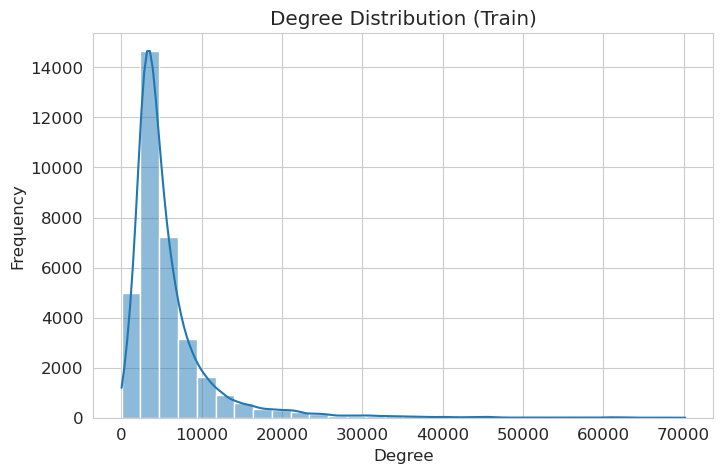

In [79]:
adj_matrices = train_analyzer.get_snapshots_adjacency_matrix()
degrees = []
for adj in adj_matrices:
        deg = np.sum(adj, axis=1)
        degrees.extend(deg)
plt.figure(figsize=(8, 5))
sns.histplot(degrees, bins=30, kde=True)
plt.title('Degree Distribution (Train)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

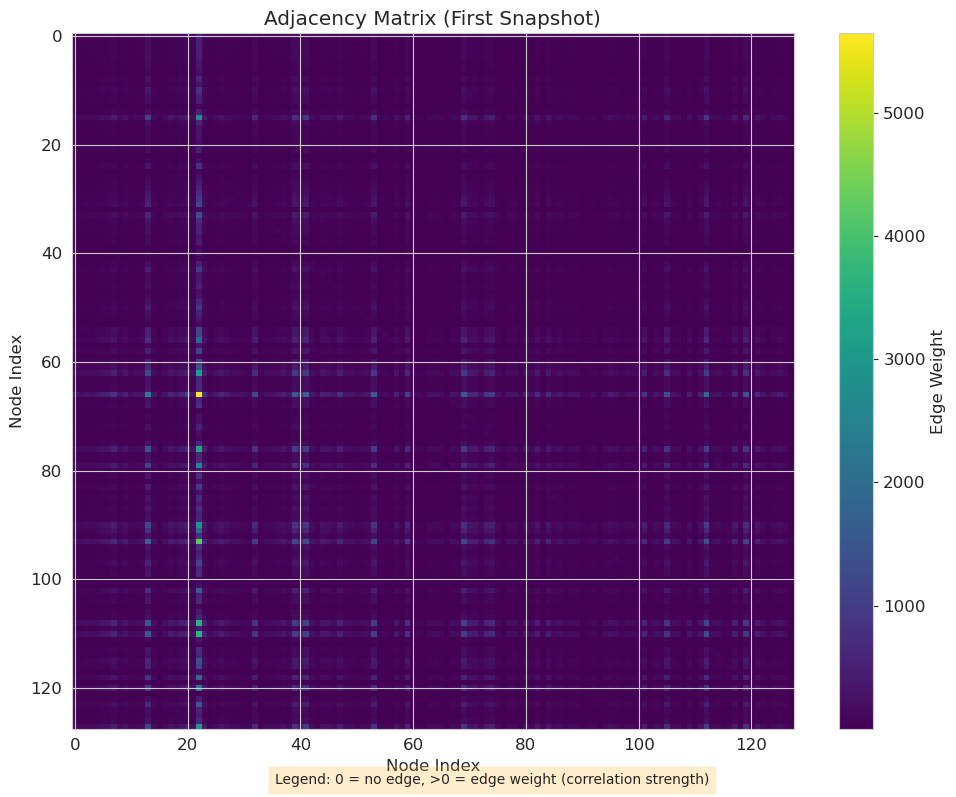

In [80]:
# Display the adjacency matrix with colorbar and legend
plt.figure(figsize=(10, 8))
im = plt.imshow(adj_matrices[0], cmap='viridis', aspect='auto')
plt.title('Adjacency Matrix (First Snapshot)')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.colorbar(im, label='Edge Weight')
plt.figtext(0.5, 0.01, "Legend: 0 = no edge, >0 = edge weight (correlation strength)", 
           ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Node Index of Most Correlated Stock')

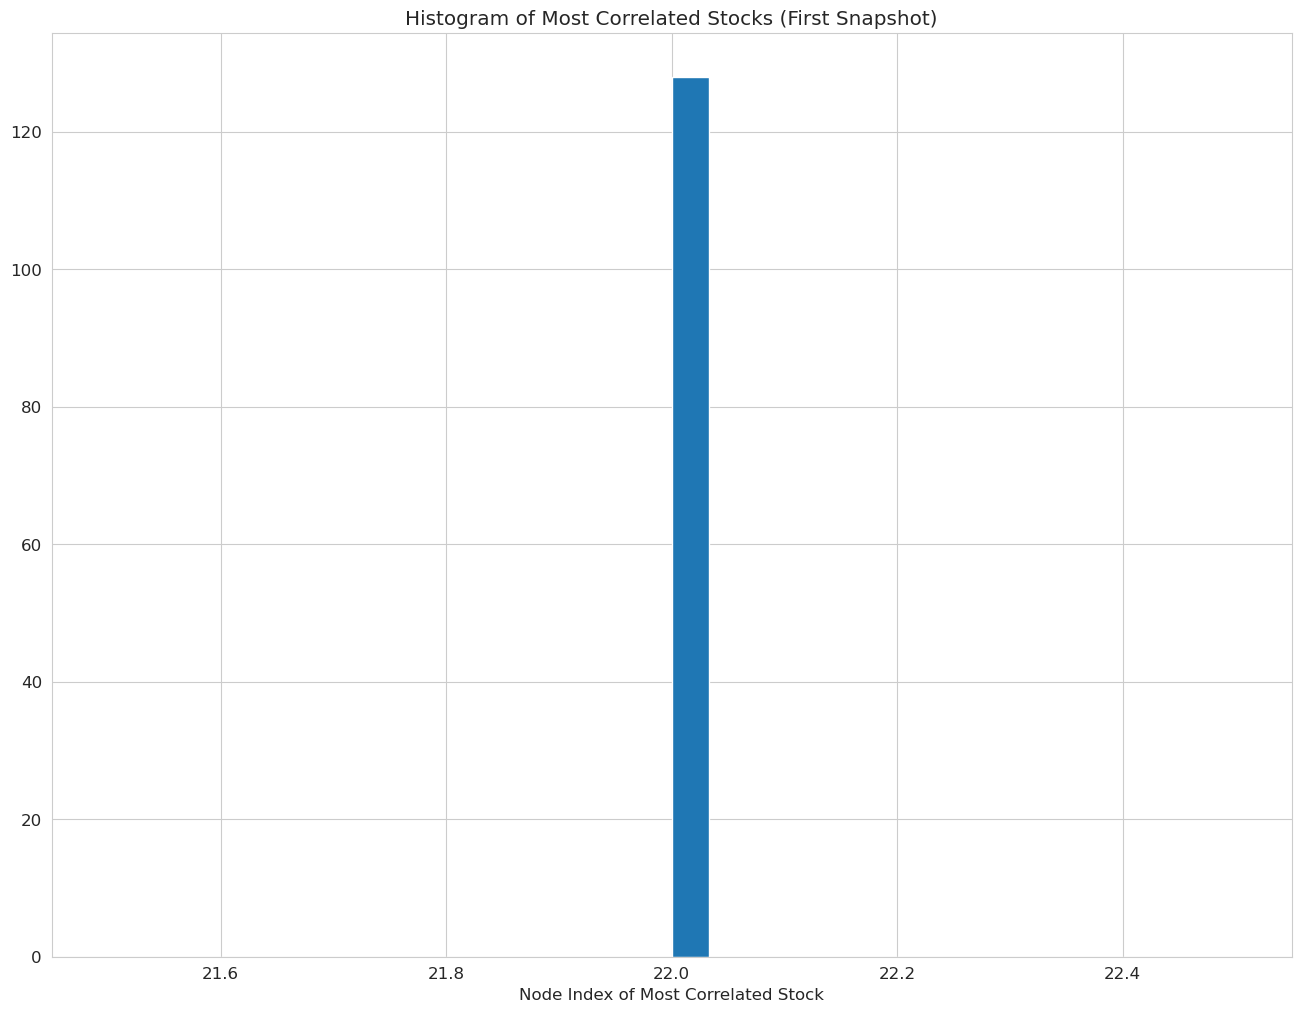

In [81]:
argmaxes_name = [ train_analyzer.index_to_stock[(adj_matrices[0][i].argmax().item())] for i in range(adj_matrices[0].shape[0]) ]
argmaxes = [ adj_matrices[0][i].argmax().item() for i in range(adj_matrices[0].shape[0]) ]
plt.hist(argmaxes, bins=30)
plt.title('Histogram of Most Correlated Stocks (First Snapshot)')
plt.xlabel('Node Index of Most Correlated Stock')

In [82]:
# Analyze distribution of adjacency matrix values (edge weights)
if not skip_adj_distribution_analysis:
    edge_weights = []
    for adj in adj_matrices:
        # Get only the non-zero values (actual edges)
        non_zero_weights = adj[adj > 0]
        if len(non_zero_weights) > 0:
            edge_weights.extend(non_zero_weights)

    plt.figure(figsize=(10, 6))
    sns.histplot(edge_weights, bins=100, kde=True)
    plt.title('Edge Weight Distribution in Adjacency Matrices (Train)')
    plt.xlabel('Edge Weight')
    plt.ylabel('Frequency')
    plt.axvline(np.mean(edge_weights), color='red', linestyle='--', label=f'Mean: {np.mean(edge_weights):.4f}')
    plt.axvline(np.median(edge_weights), color='green', linestyle=':', label=f'Median: {np.median(edge_weights):.4f}')
    plt.legend()
    plt.show()

    # Summary statistics of edge weights
    edge_stats = pd.Series(edge_weights).describe()
    print("Edge Weight Statistics:")
    print(edge_stats)

## Node Features Analysis
Explore the distribution and statistics of node features across snapshots.

In [83]:
train_analyzer.analyze_node_features().groupby('ticker').describe()

Close                                                              \
        count      mean       std       min       25%       50%       75%   
ticker                                                                      
600000  271.0  0.705160  0.067995  0.550011  0.648337  0.725539  0.749099   
600009  271.0  0.676879  0.260469  0.450946  0.528331  0.563053  0.629963   
600010  271.0  0.702687  0.067828  0.594407  0.648123  0.686931  0.746494   
600011  271.0  0.704017  0.084387  0.559690  0.648831  0.680026  0.758786   
600015  271.0  0.703887  0.128861  0.496395  0.608320  0.691940  0.819990   
...       ...       ...       ...       ...       ...       ...       ...   
601919  271.0  0.702576  0.119441  0.564185  0.610556  0.656103  0.791507   
601988  271.0  0.705019  0.101690  0.476819  0.659433  0.703975  0.799155   
601998  271.0  0.704965  0.160234  0.403707  0.610710  0.680971  0.854988   
603288  271.0  0.683861  0.211109  0.491134  0.565038  0.607171  0.646452   
603993  271.0  0.695864  0.189522  0.272539  0.555957  0.664037  0.785486   

                   High            ...    Volume           snapshot_idx  \
             max  count      mean  ...       75%       max        count   
ticker                             ...                                    
600000  0.841530  271.0  0.704899  ...  0.323289  3.452787        271.0   
600009  1.348674  271.0  0.676298  ...  0.731208  1.835334        271.0   
600010  0.840112  271.0  0.702410  ...  0.814319  2.020946        271.0   
600011  0.904879  271.0  0.703655  ...  0.933154  1.713304        271.0   
600015  0.919695  271.0  0.703481  ...  0.627514  2.768737        271.0   
...          ...    ...       ...  ...       ...       ...          ...   
601919  0.986090  271.0  0.702183  ...  0.685441  2.560873        271.0   
601988  0.843690  271.0  0.704960  ...  0.790862  1.792694        271.0   
601998  0.954525  271.0  0.704810  ...  0.716110  1.987356        271.0   
603288  1.301458  271.0  0.682835  ...  0.726603  2.069907        271.0   
603993  1.125025  271.0  0.695327  ...  0.914201  2.264096        271.0   

                                                          
         mean        std  min   25%    50%    75%    max  
ticker                                                    
600000  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
600009  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
600010  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
600011  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
600015  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
...       ...        ...  ...   ...    ...    ...    ...  
601919  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
601988  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
601998  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
603288  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  
603993  135.0  78.375166  0.0  67.5  135.0  202.5  270.0  

[125 rows x 48 columns]

ENHANCED NODE FEATURE ANALYSIS


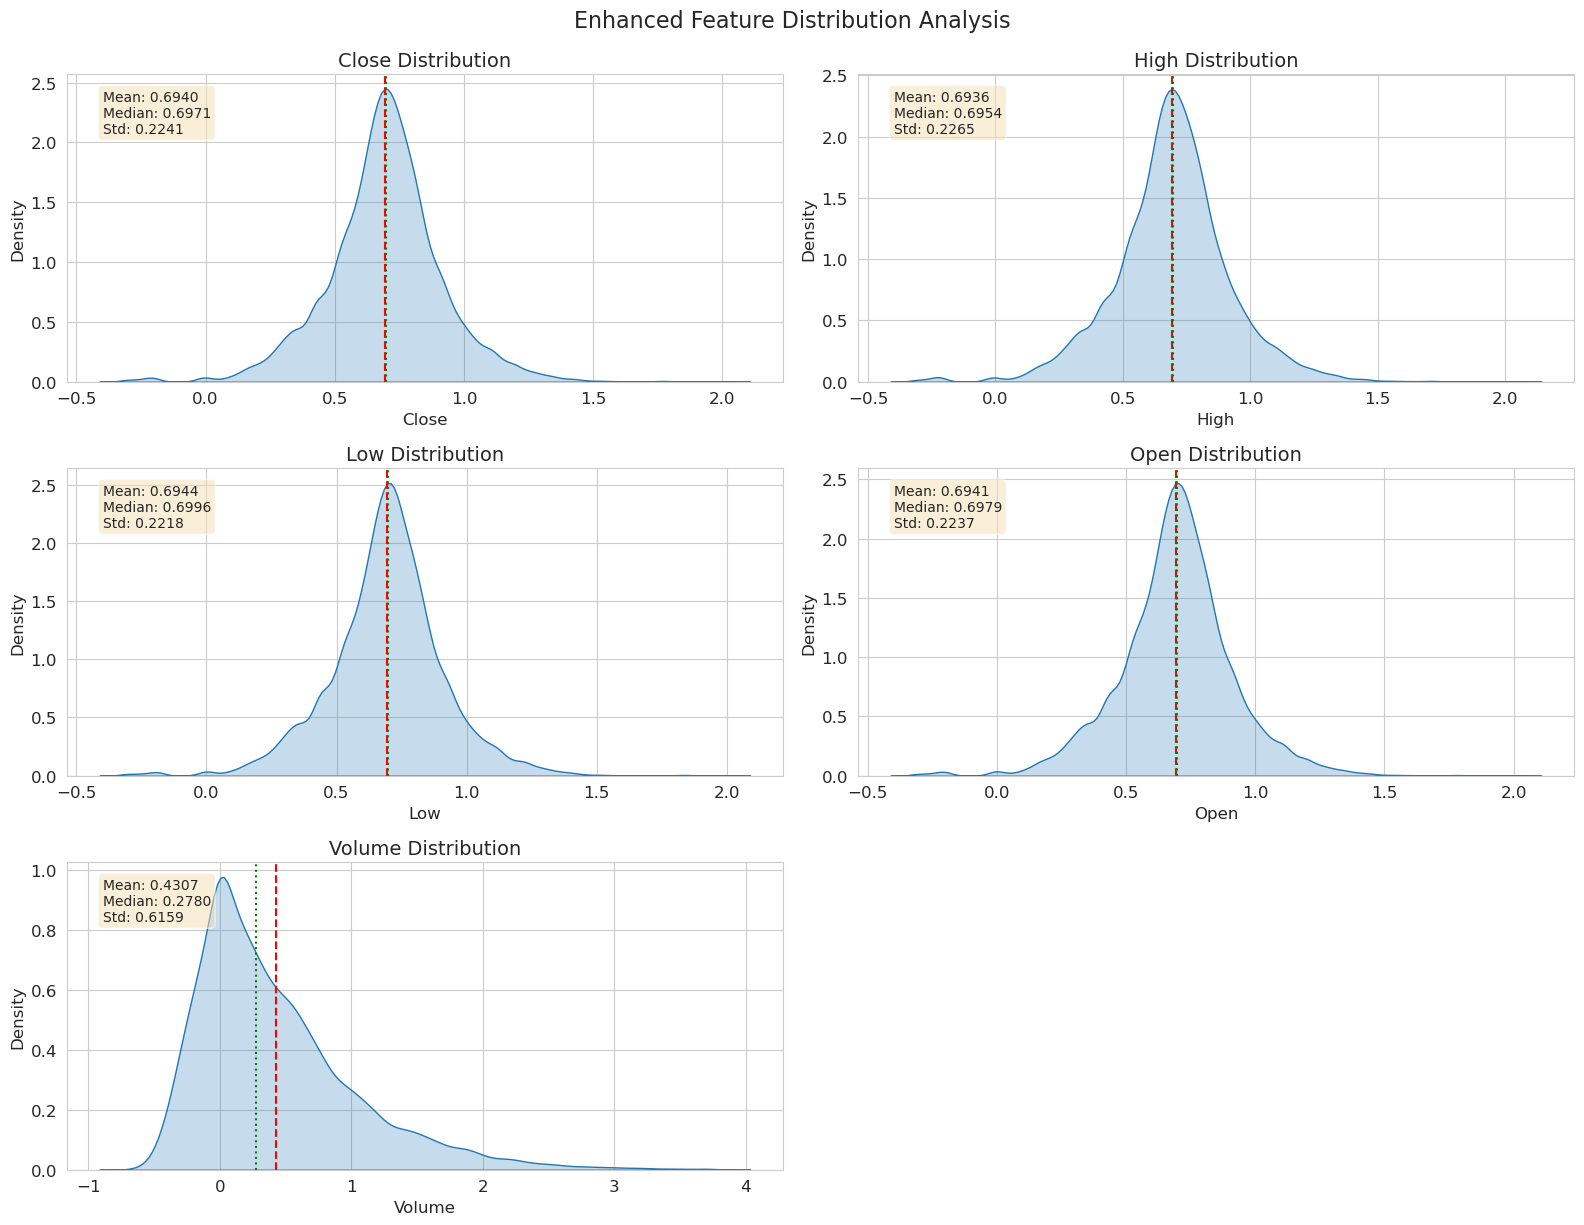


== Derived Features Statistics ==


,volatility,daily_return,volume_price_ratio
count,34688.000000,34688.000000,34688.000000
mean,-0.000772,0.000207,0.743015
std,0.018464,0.146158,37.639877
min,-0.119789,-15.612730,-1644.614746
25%,-0.012048,-0.007831,0.000000
50%,-0.003447,-0.000845,0.410467
75%,0.007711,0.006623,0.975532
max,0.108419,16.575449,6445.002441


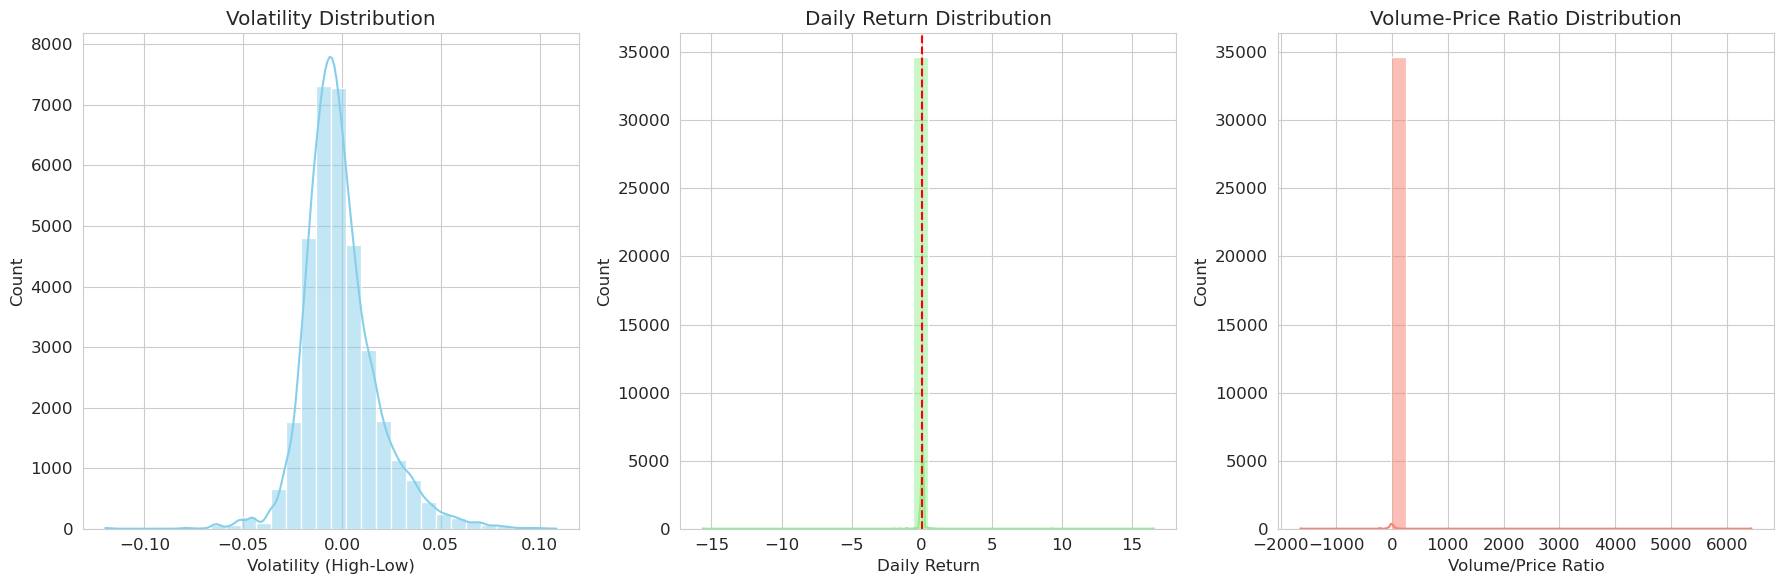

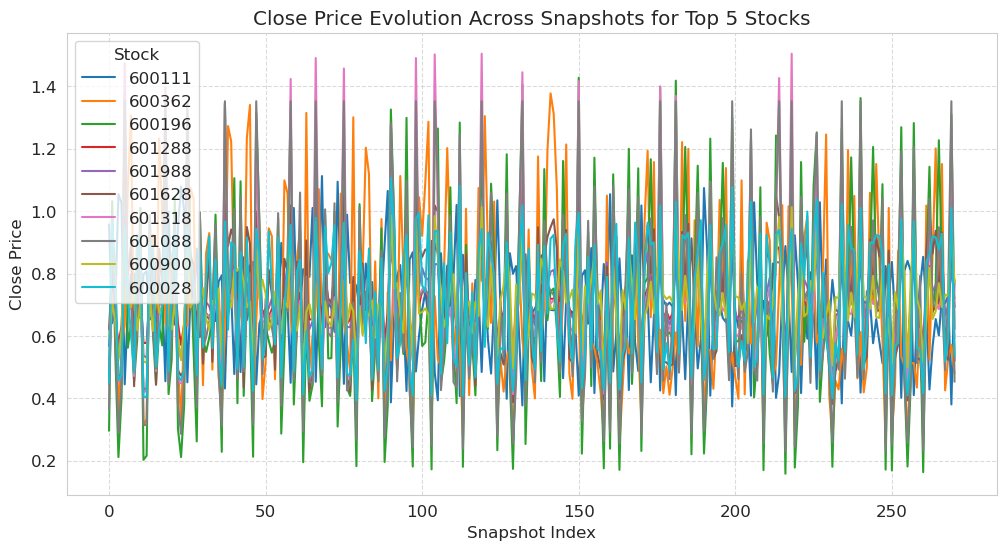

<Figure size 1200x1000 with 0 Axes>

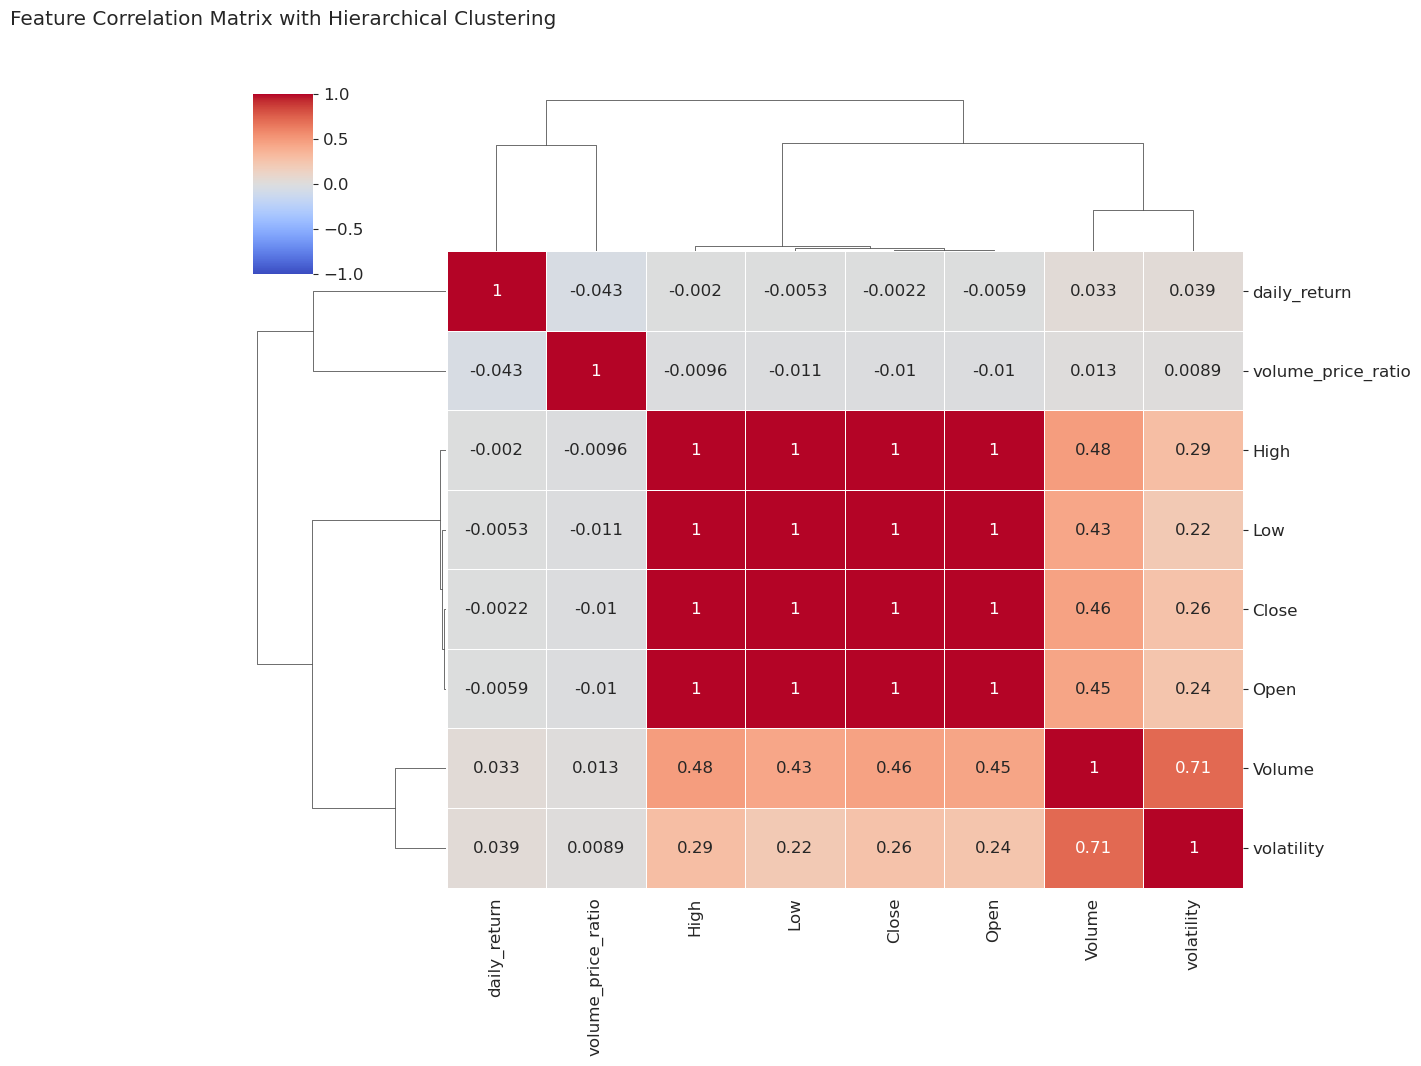

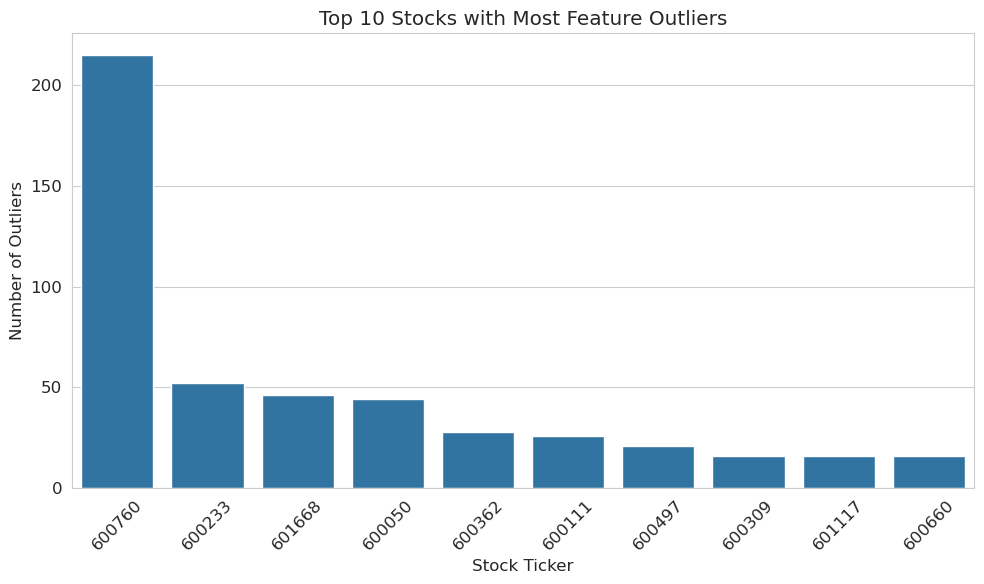

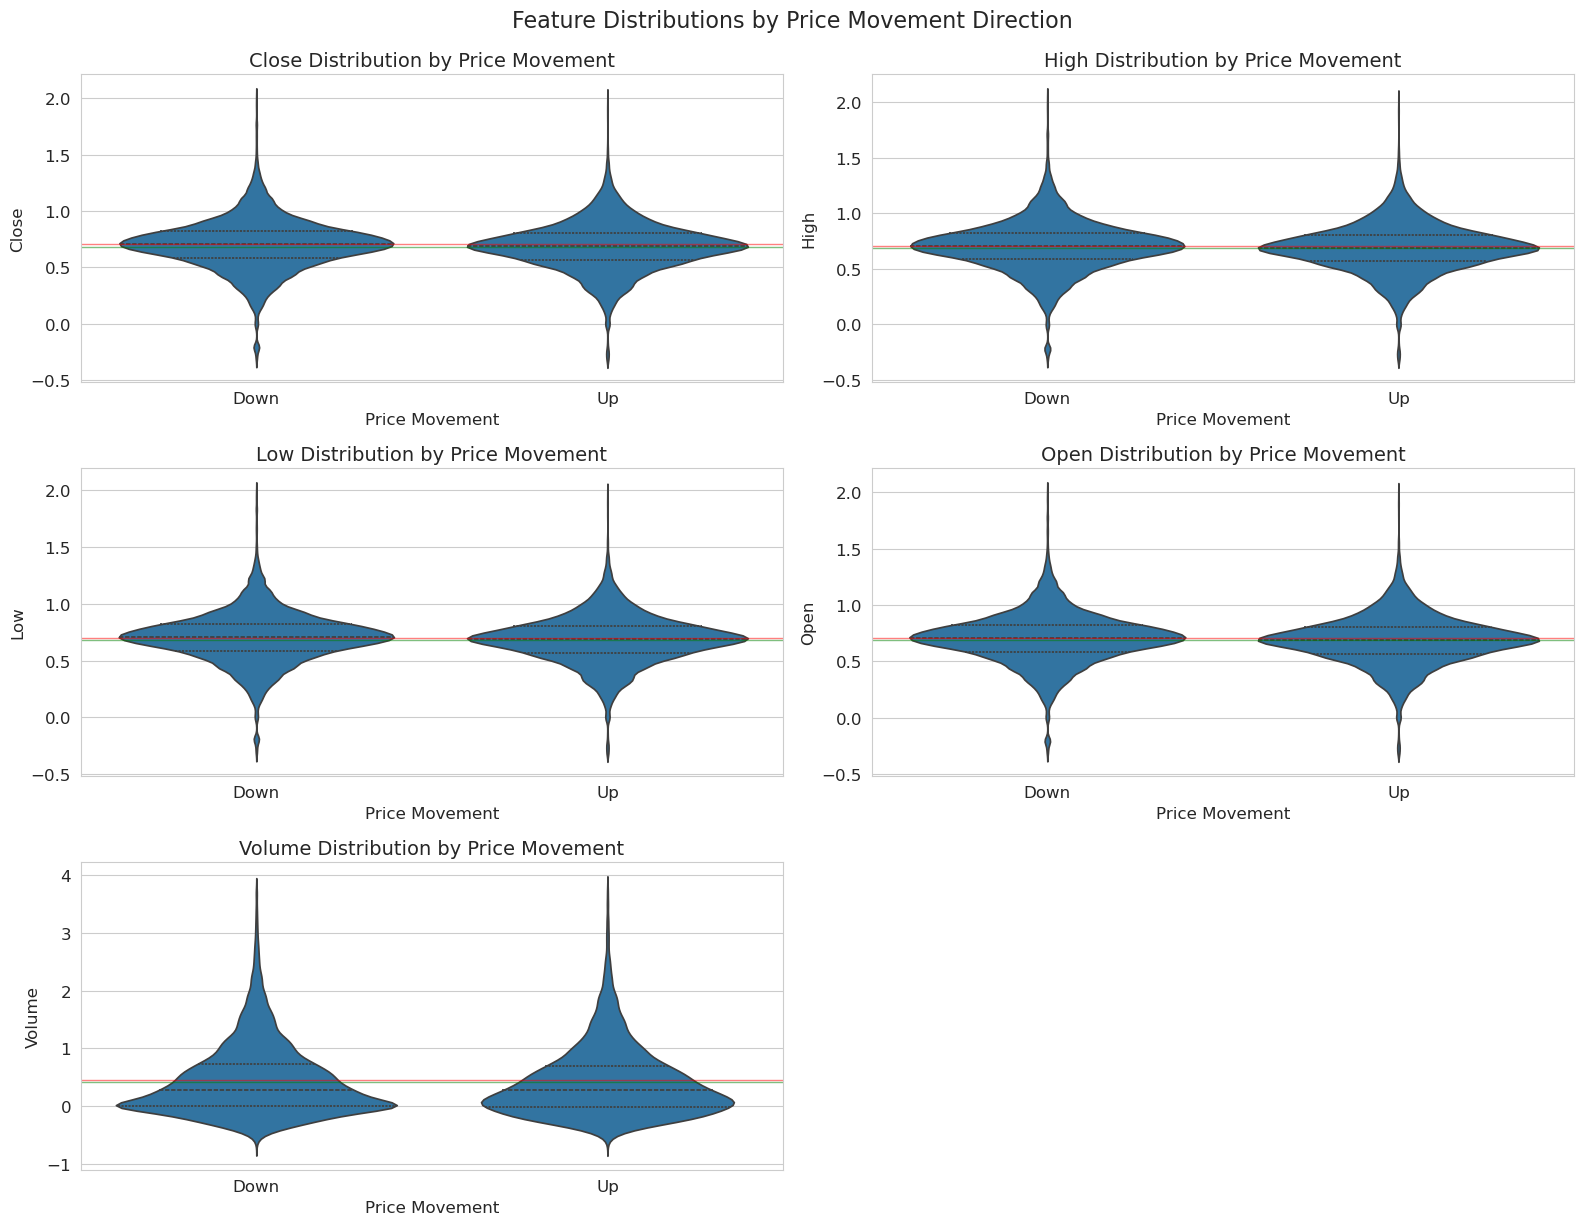

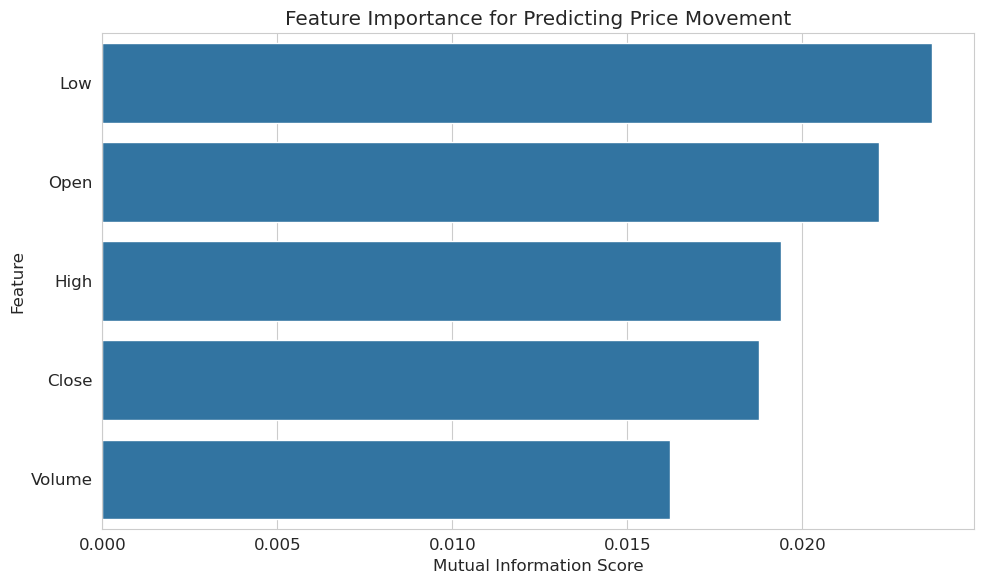

In [84]:
print("=" * 80)
print("ENHANCED NODE FEATURE ANALYSIS")
print("=" * 80)

# Get the feature data
train_features_df = train_analyzer.analyze_node_features()

# 1. Feature Distribution Analysis with Advanced Visualization
plt.figure(figsize=(16, 12))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(3, 2, i)
    # Use kernel density estimation for smoother visualization
    sns.kdeplot(data=train_features_df, x=feature, fill=True)
    plt.title(f'{feature} Distribution', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    # Add statistics to the plot
    mean_val = train_features_df[feature].mean()
    median_val = train_features_df[feature].median()
    std_val = train_features_df[feature].std()
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
    plt.axvline(median_val, color='green', linestyle=':', label=f'Median: {median_val:.4f}')
    
    # Add text box with statistics
    stats_text = f"Mean: {mean_val:.4f}\nMedian: {median_val:.4f}\nStd: {std_val:.4f}"
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.suptitle('Enhanced Feature Distribution Analysis', fontsize=16, y=1.02)
plt.show()

# 2. Calculate and analyze derived features
derived_features_df = train_analyzer.calculate_derived_features(train_features_df)

# Display summary of derived features
print("\n== Derived Features Statistics ==")
derived_stats = derived_features_df[['volatility', 'daily_return', 'volume_price_ratio']].describe()
display(derived_stats)

# Visualize derived features
plt.figure(figsize=(18, 6))

# Volatility distribution
plt.subplot(1, 3, 1)
sns.histplot(derived_features_df['volatility'], kde=True, bins=30, color='skyblue')
plt.title('Volatility Distribution')
plt.xlabel('Volatility (High-Low)')

# Daily return distribution
plt.subplot(1, 3, 2)
sns.histplot(derived_features_df['daily_return'], kde=True, bins=30, color='lightgreen')
plt.title('Daily Return Distribution')
plt.xlabel('Daily Return')
plt.axvline(0, color='red', linestyle='--')

# Volume-price ratio
plt.subplot(1, 3, 3)
sns.histplot(derived_features_df['volume_price_ratio'], kde=True, bins=30, color='salmon')
plt.title('Volume-Price Ratio Distribution')
plt.xlabel('Volume/Price Ratio')

plt.tight_layout()
plt.show()

# 3. Time Series Analysis of Features
# Get Close price time series for top 5 stocks by market cap (for example)
top_stocks = train_features_df['ticker'].value_counts().head(10).index.tolist()
close_ts_data = pd.DataFrame()

for stock in top_stocks:
    ts_data = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    close_ts_data = pd.concat([close_ts_data, ts_data])

# Plot time series
plt.figure(figsize=(12, 6))
sns.lineplot(data=close_ts_data, x='snapshot', y='value', hue='ticker')
plt.title('Close Price Evolution Across Snapshots for Top 5 Stocks')
plt.xlabel('Snapshot Index')
plt.ylabel('Close Price')
plt.legend(title='Stock')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Feature Correlation Heatmap with Clustering
plt.figure(figsize=(12, 10))
# Include derived features in correlation analysis
corr_columns = train_analyzer.features + ['volatility', 'daily_return', 'volume_price_ratio']
corr_matrix = derived_features_df[corr_columns].corr()

# Use hierarchical clustering to group correlated features
g = sns.clustermap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    figsize=(12, 10)
)
plt.title('Feature Correlation Matrix with Hierarchical Clustering', pad=50)
plt.show()

# 5. Outlier Analysis
# Calculate Z-scores for each feature
z_scores = {}
for feature in train_analyzer.features:
    z_scores[feature] = (train_features_df[feature] - train_features_df[feature].mean()) / train_features_df[feature].std()

# Identify potential outliers (|z-score| > 3)
outliers_df = pd.DataFrame(z_scores)
outliers_df['ticker'] = train_features_df['ticker']
outliers_df['snapshot_idx'] = train_features_df['snapshot_idx']
outliers_df['is_outlier'] = (abs(outliers_df[train_analyzer.features]) > 3).any(axis=1)

# Count outliers by ticker
outlier_counts = outliers_df[outliers_df['is_outlier']].ticker.value_counts()
top_outlier_tickers = outlier_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_outlier_tickers.index, y=top_outlier_tickers.values)
plt.title('Top 10 Stocks with Most Feature Outliers')
plt.xlabel('Stock Ticker')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Node Feature Analysis by Target (Up/Down) - More Advanced
feature_target_df = train_features_df.copy()
# Add target information
feature_target_df['target'] = np.nan  # Initialize with NaN

# Populate target values from each snapshot
for i in range(train_analyzer.num_snapshots):
    snapshot = train_analyzer.graph_snapshots[i]
    targets = snapshot.y.numpy()
    mask = (feature_target_df['snapshot_idx'] == i)
    feature_target_df.loc[mask, 'target'] = np.tile(targets, mask.sum() // len(targets))

feature_target_df['target_category'] = np.where(feature_target_df['target'] > 0, 'Up', 'Down')

# Create violin plots to show distribution differences
plt.figure(figsize=(16, 12))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(3, 2, i)
    sns.violinplot(x='target_category', y=feature, data=feature_target_df, inner='quartile')
    plt.title(f'{feature} Distribution by Price Movement', fontsize=14)
    plt.xlabel('Price Movement', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    
    # Add mean lines
    means = feature_target_df.groupby('target_category')[feature].mean()
    plt.axhline(y=means['Up'], color='green', linestyle='-', linewidth=1, alpha=0.5)
    plt.axhline(y=means['Down'], color='red', linestyle='-', linewidth=1, alpha=0.5)
    
plt.tight_layout()
plt.suptitle('Feature Distributions by Price Movement Direction', fontsize=16, y=1.02)
plt.show()

# 8. Feature Importance for Predicting Price Movement
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information between features and target
X = feature_target_df[train_analyzer.features] #+ ['volatility', 'daily_return', 'volume_price_ratio']]
y = (feature_target_df['target'] > 0).astype(int)  # 1 for Up, 0 for Down

# Handle NaN values
X = X.fillna(X.mean())
valid_mask = ~y.isna()
X_valid = X[valid_mask]
y_valid = y[valid_mask]

mi_scores = mutual_info_classif(X_valid, y_valid)
mi_results = pd.Series(mi_scores, index=X.columns)
mi_results = mi_results.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_results.values, y=mi_results.index)
plt.title('Feature Importance for Predicting Price Movement')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Adjacency Matrix Comparison
Compare adjacency matrices across different snapshots to observe temporal changes in the graph structure.

/tmp/ipykernel_1640288/1645740391.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


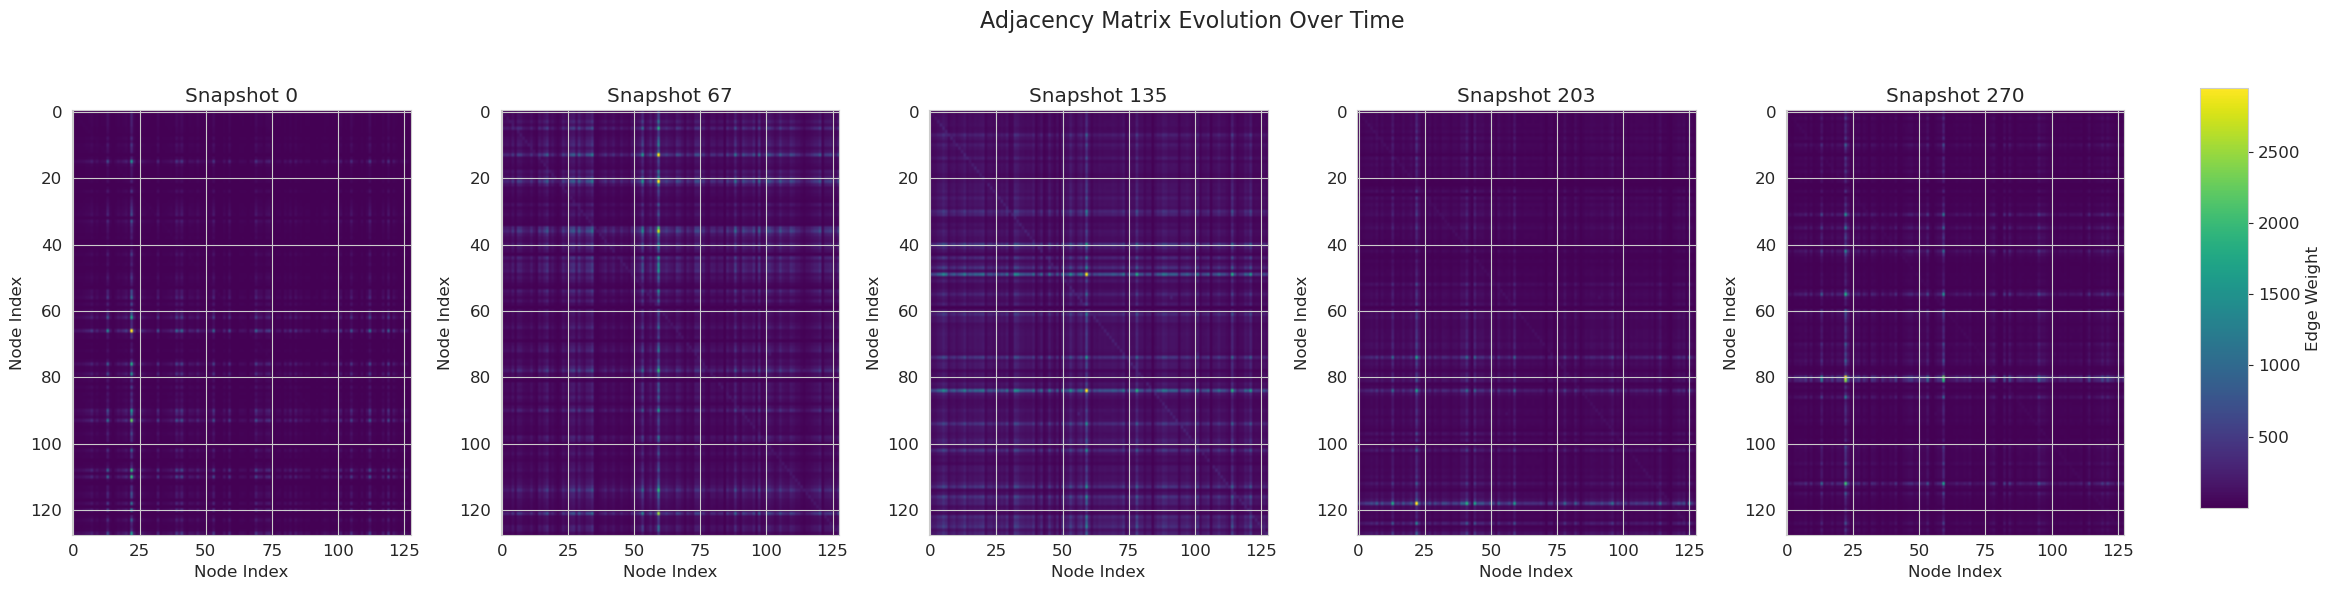

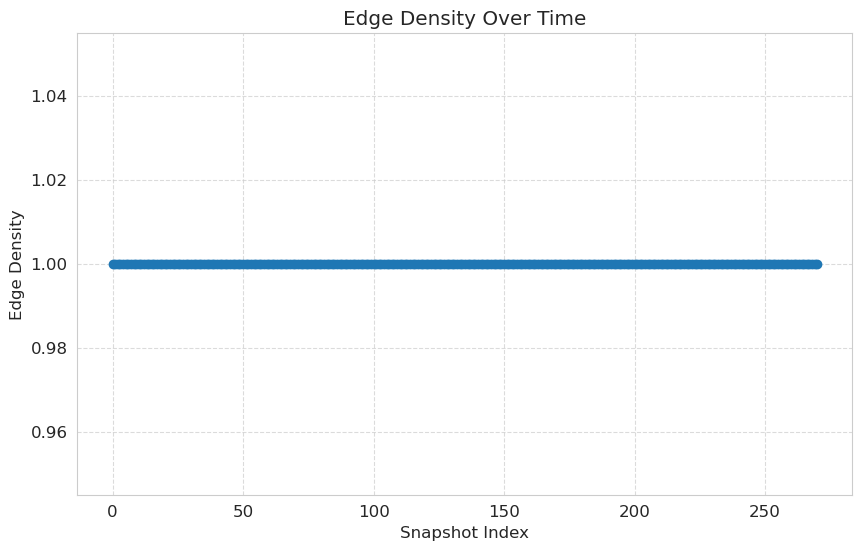

In [85]:
# Compare adjacency matrices at different time points
if len(adj_matrices) >= 5:
    snapshot_indices = [0, len(adj_matrices)//4, len(adj_matrices)//2, 3*len(adj_matrices)//4, len(adj_matrices)-1]  # First, middles, last
    fig, axes = plt.subplots(1, 5, figsize=(24, 6))

    for i, idx in enumerate(snapshot_indices):
        im = axes[i].imshow(adj_matrices[idx], cmap='viridis', aspect='auto')
        axes[i].set_title(f'Snapshot {idx}')
        axes[i].set_xlabel('Node Index')
        axes[i].set_ylabel('Node Index')
    
    # Add colorbar to the right of the last image
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Edge Weight')
    
    plt.suptitle('Adjacency Matrix Evolution Over Time', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()
    
    # Analyze how edge density changes over time
    edge_density = [np.count_nonzero(adj)/adj.size for adj in adj_matrices]
    plt.figure(figsize=(10, 6))
    plt.plot(edge_density, 'o-')
    plt.title('Edge Density Over Time')
    plt.xlabel('Snapshot Index')
    plt.ylabel('Edge Density')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## Homophily Analysis
Calculate and visualize homophily for each snapshot (fraction of edges connecting nodes with the same label).

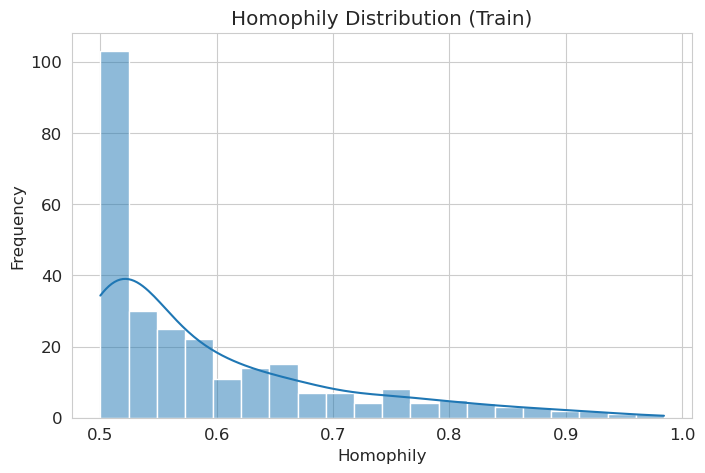

In [86]:
homophily_scores = []

analyzer = train_analyzer

for sample_idx in range(len(analyzer.graph_snapshots)):
    homophily_score = analyzer.get_homophily_score(sample_idx)
    homophily_scores.append(homophily_score)


plt.figure(figsize=(8, 5))
sns.histplot(homophily_scores, bins=20, kde=True)
plt.title('Homophily Distribution (Train)')
plt.xlabel('Homophily')
plt.ylabel('Frequency')
plt.show()

## Up Ratios Analysis
Visualize the distribution of up ratios (fraction of nodes with positive label) for each dataset.

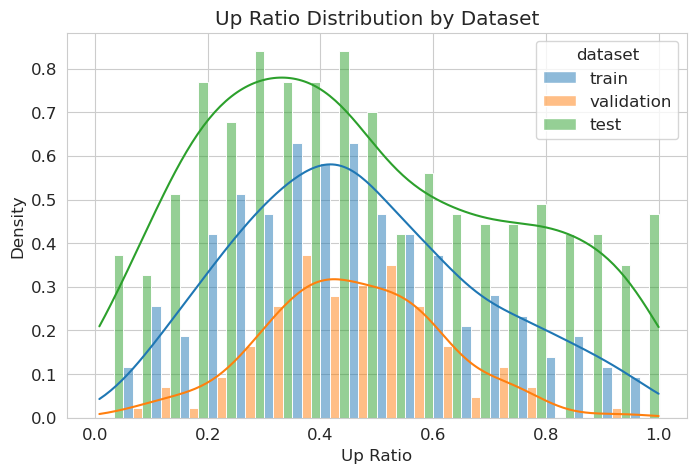

In [87]:
plt.figure(figsize=(8, 5))
sns.histplot(data=all_snapshots_df, x='up_ratio', hue='dataset', multiple='dodge', kde=True, binrange=(0, 1), binwidth=.05, stat='density')
plt.title('Up Ratio Distribution by Dataset')
plt.xlabel('Up Ratio')
plt.ylabel('Density')
plt.show()

## Connectivity Analysis
Compare connectivity statistics across datasets.

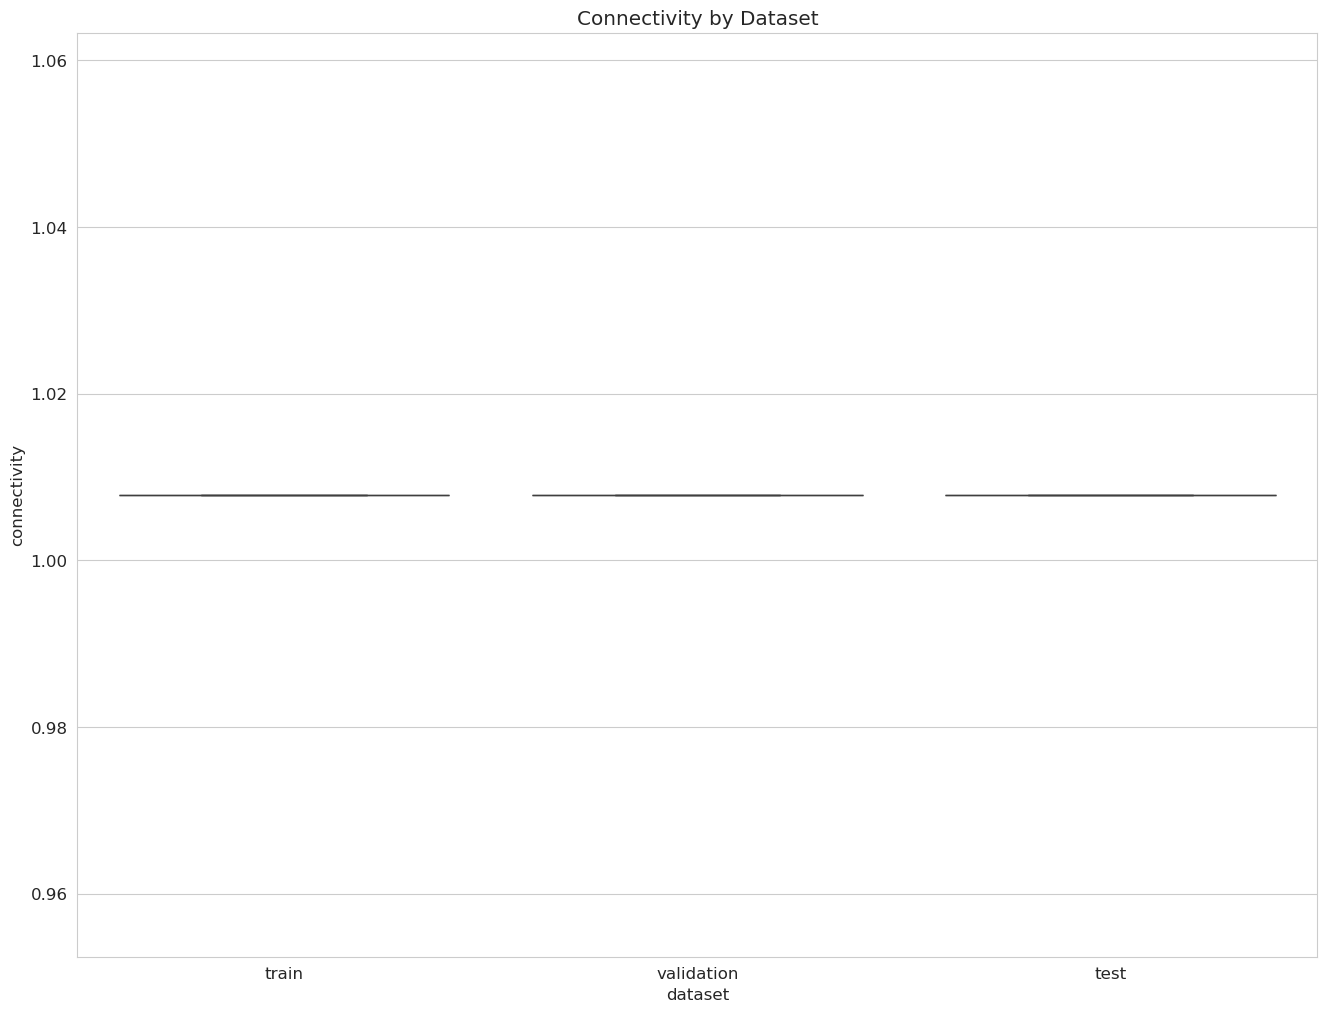

In [88]:
sns.boxplot(data=all_snapshots_df, x='dataset', y='connectivity')
plt.title('Connectivity by Dataset')
plt.show()

## Summary Statistics
Show summary statistics for key metrics in each dataset.

In [89]:
summary = all_snapshots_df.groupby('dataset')[['up_ratio', 'connectivity']].describe()
summary

up_ratio                                                    \
              count      mean       std       min       25%       50%   
dataset                                                                 
test          474.0  0.467333  0.264069  0.007812  0.257812  0.429688   
train         271.0  0.467683  0.212914  0.054688  0.308594  0.445312   
validation    112.0  0.457450  0.155254  0.062500  0.363281  0.453125   

                               connectivity                                    \
                 75%       max        count      mean           std       min   
dataset                                                                         
test        0.669922  1.000000        474.0  1.007874  1.555954e-15  1.007874   
train       0.601562  0.992188        271.0  1.007874  1.557188e-15  1.007874   
validation  0.564453  0.929688        112.0  1.007874  1.561298e-15  1.007874   

                                                    
                 25%       50%       75%       max  
dataset                                             
test        1.007874  1.007874  1.007874  1.007874  
train       1.007874  1.007874  1.007874  1.007874  
validation  1.007874  1.007874  1.007874  1.007874

1. Dataset Statistics Comparison


,Dataset,Market,Time Period,Num Nodes,Num Snapshots,Window Size,Normalizer
0,Train,SSE,2016-05-01-2017-06-30,128,271,14,zscore
1,Validation,SSE,2017-07-01-2017-12-31,128,112,14,zscore
2,Test,SSE,2018-01-01-2019-12-31,128,474,14,zscore



2. Degree Distribution Analysis
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)


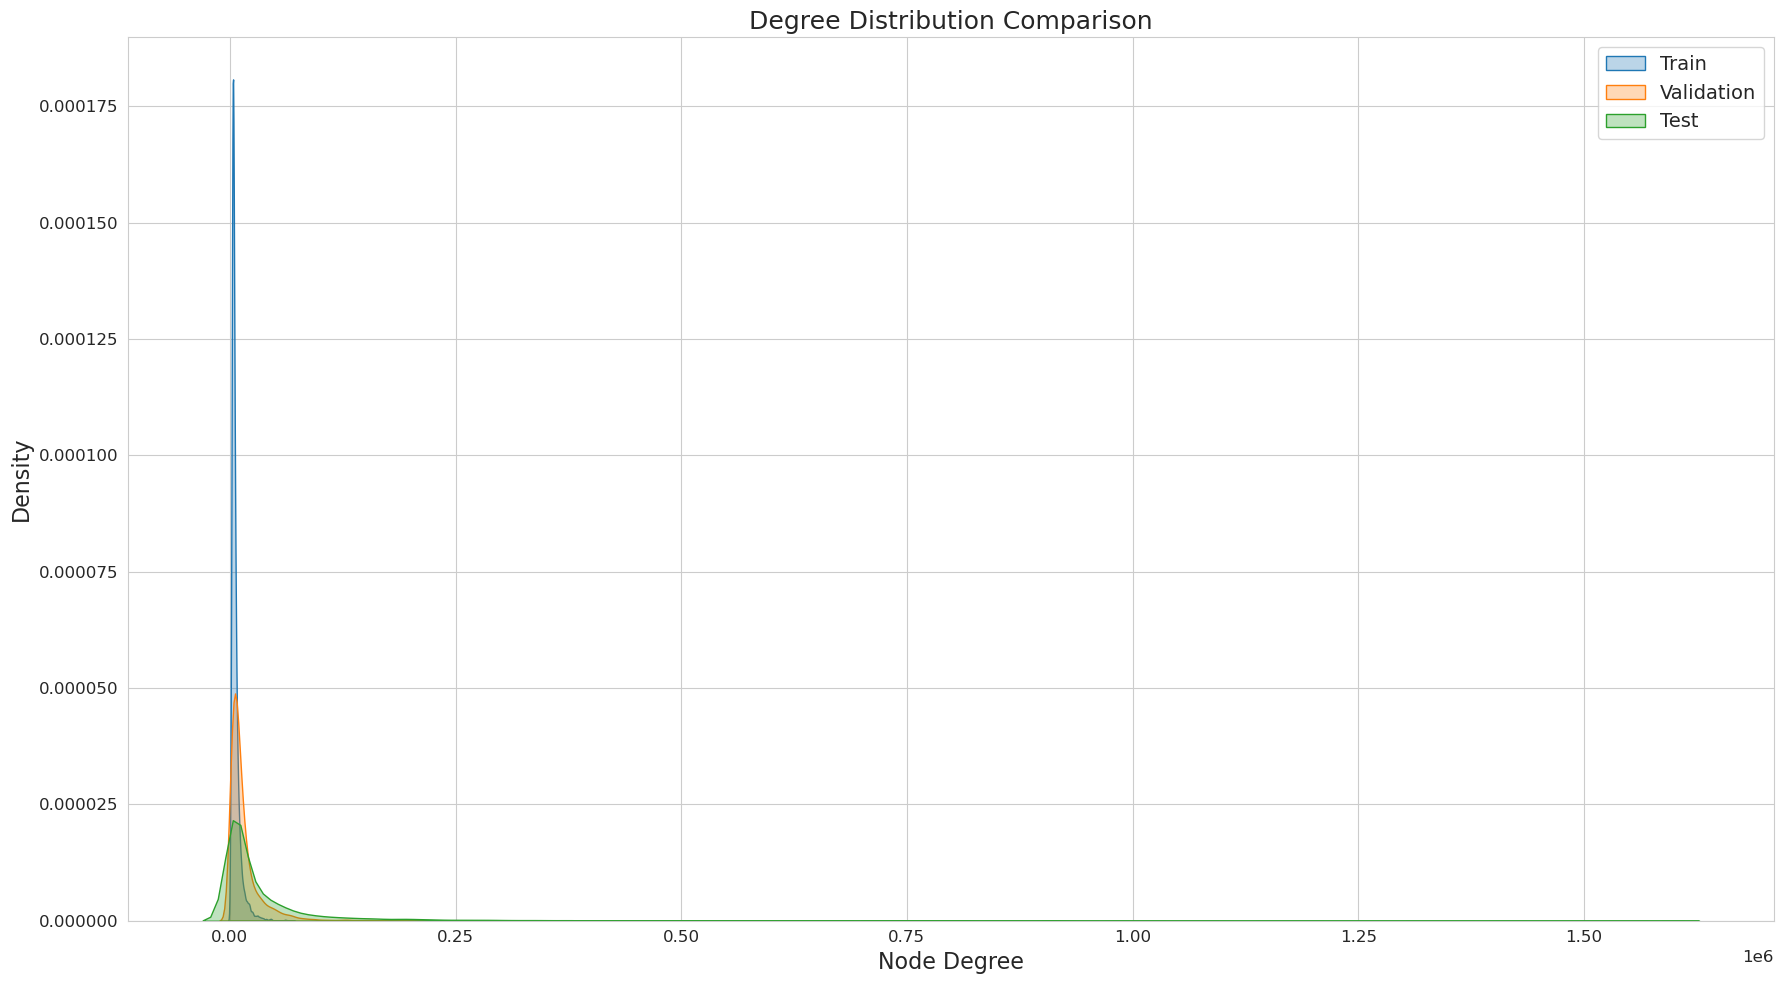


3. Snapshot Statistics Comparison


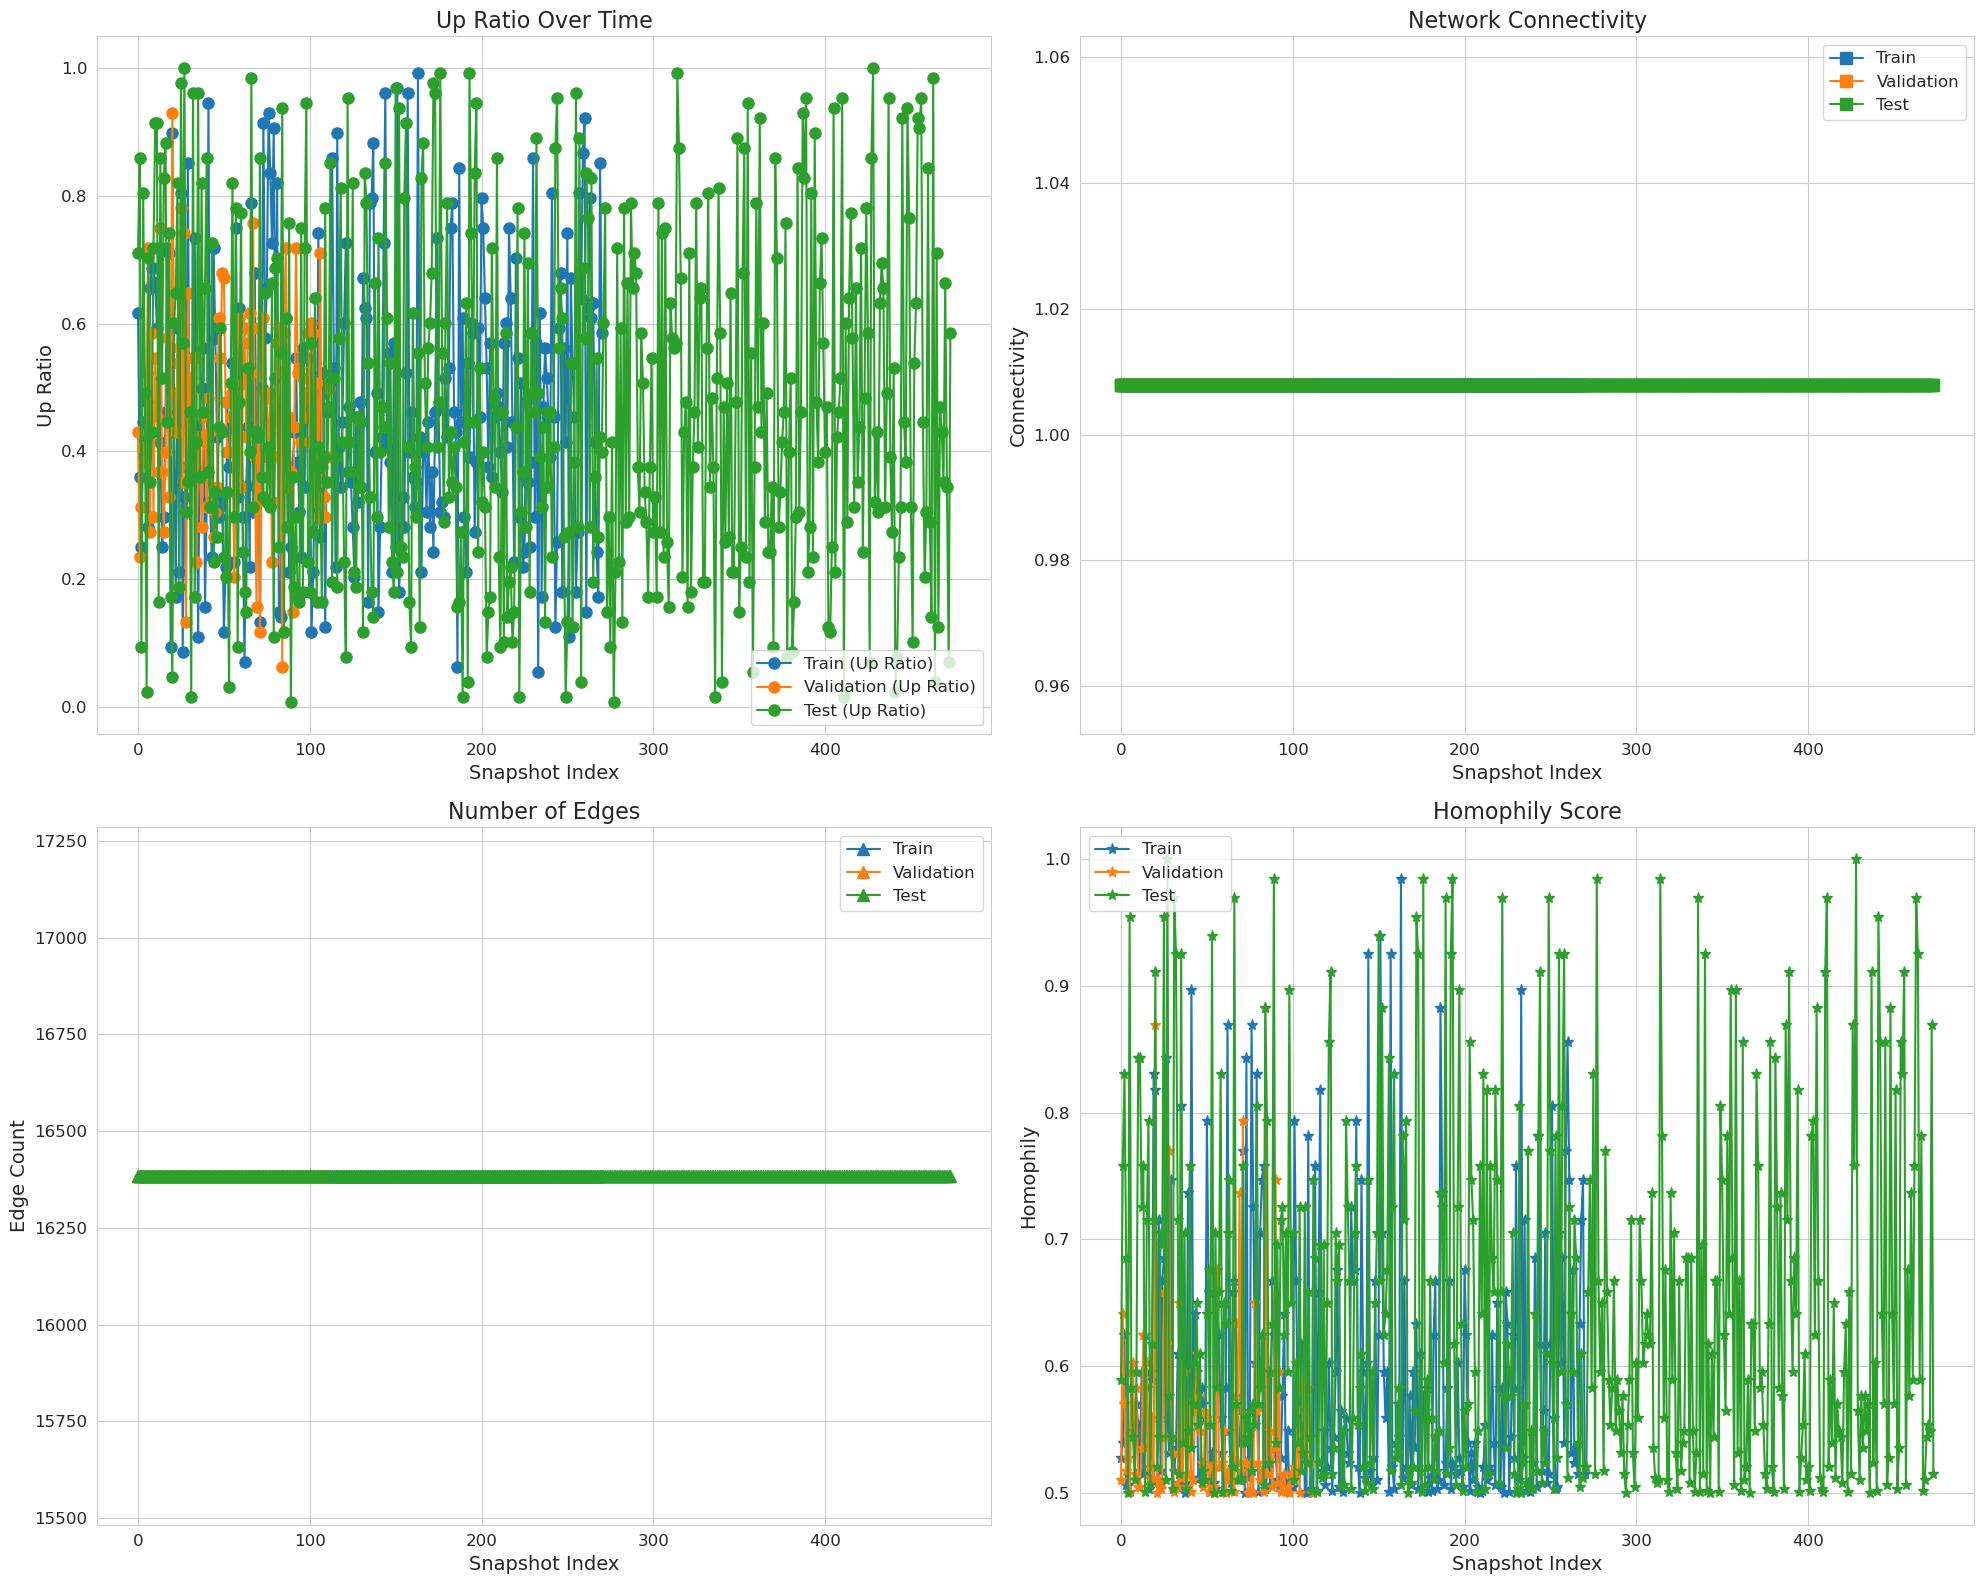


4. Feature Distributions Comparison


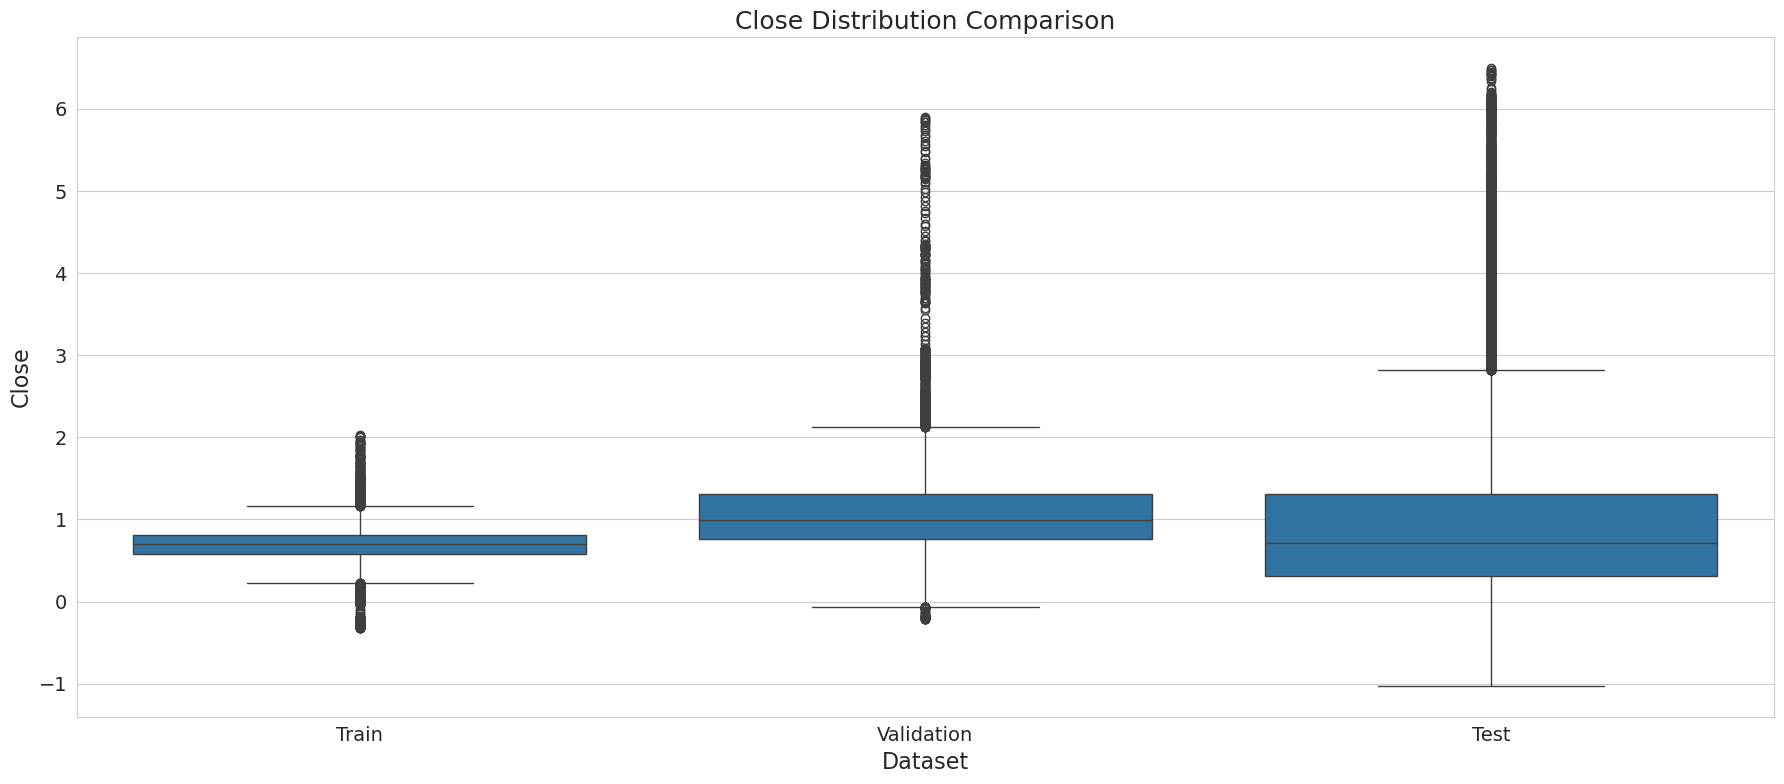

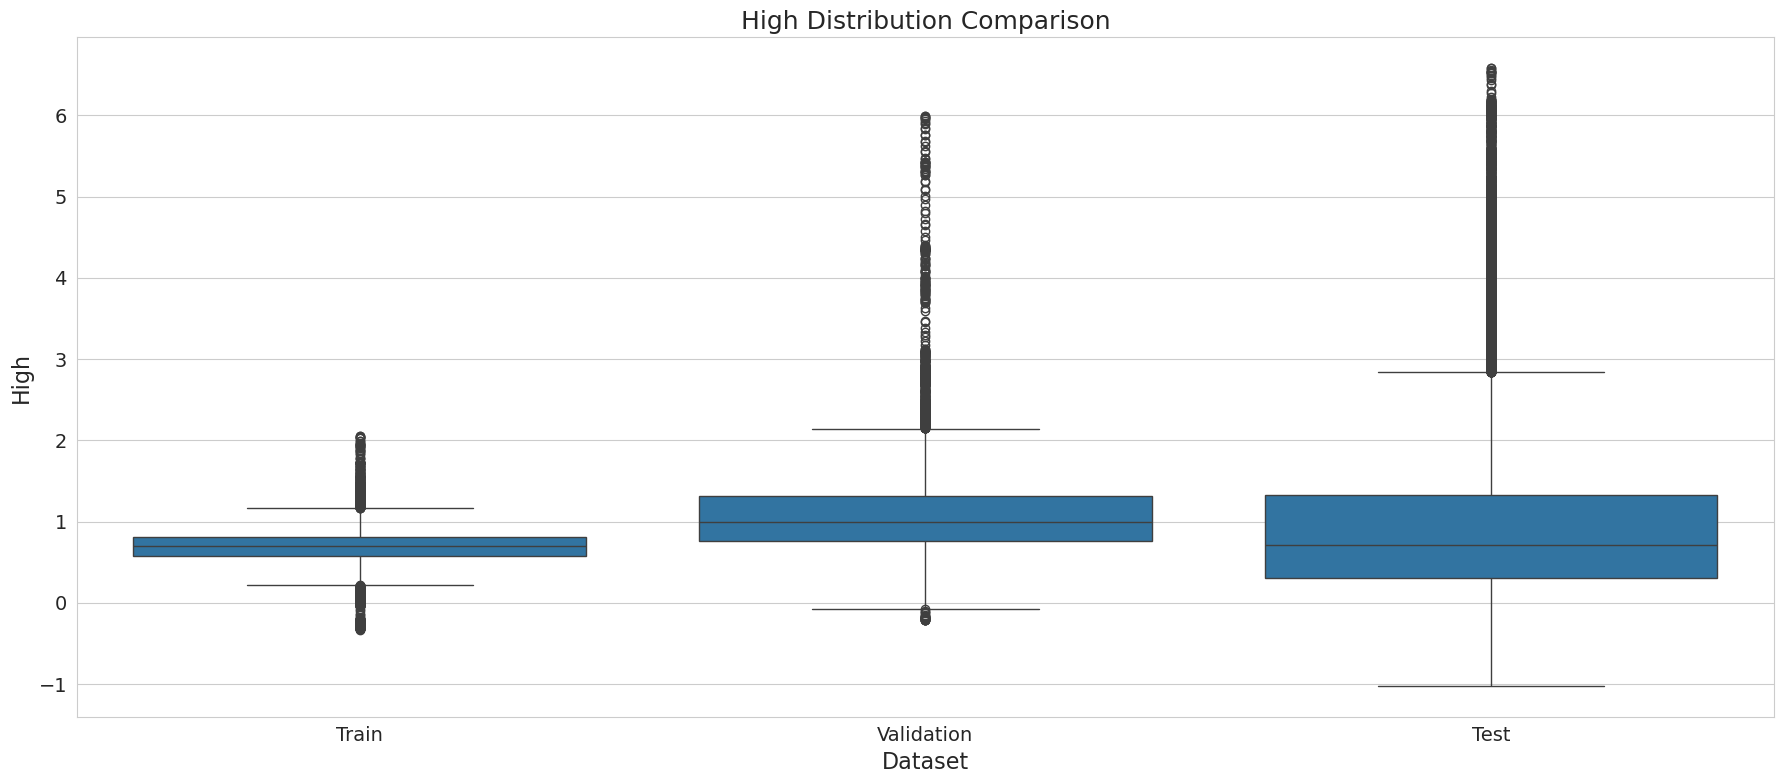

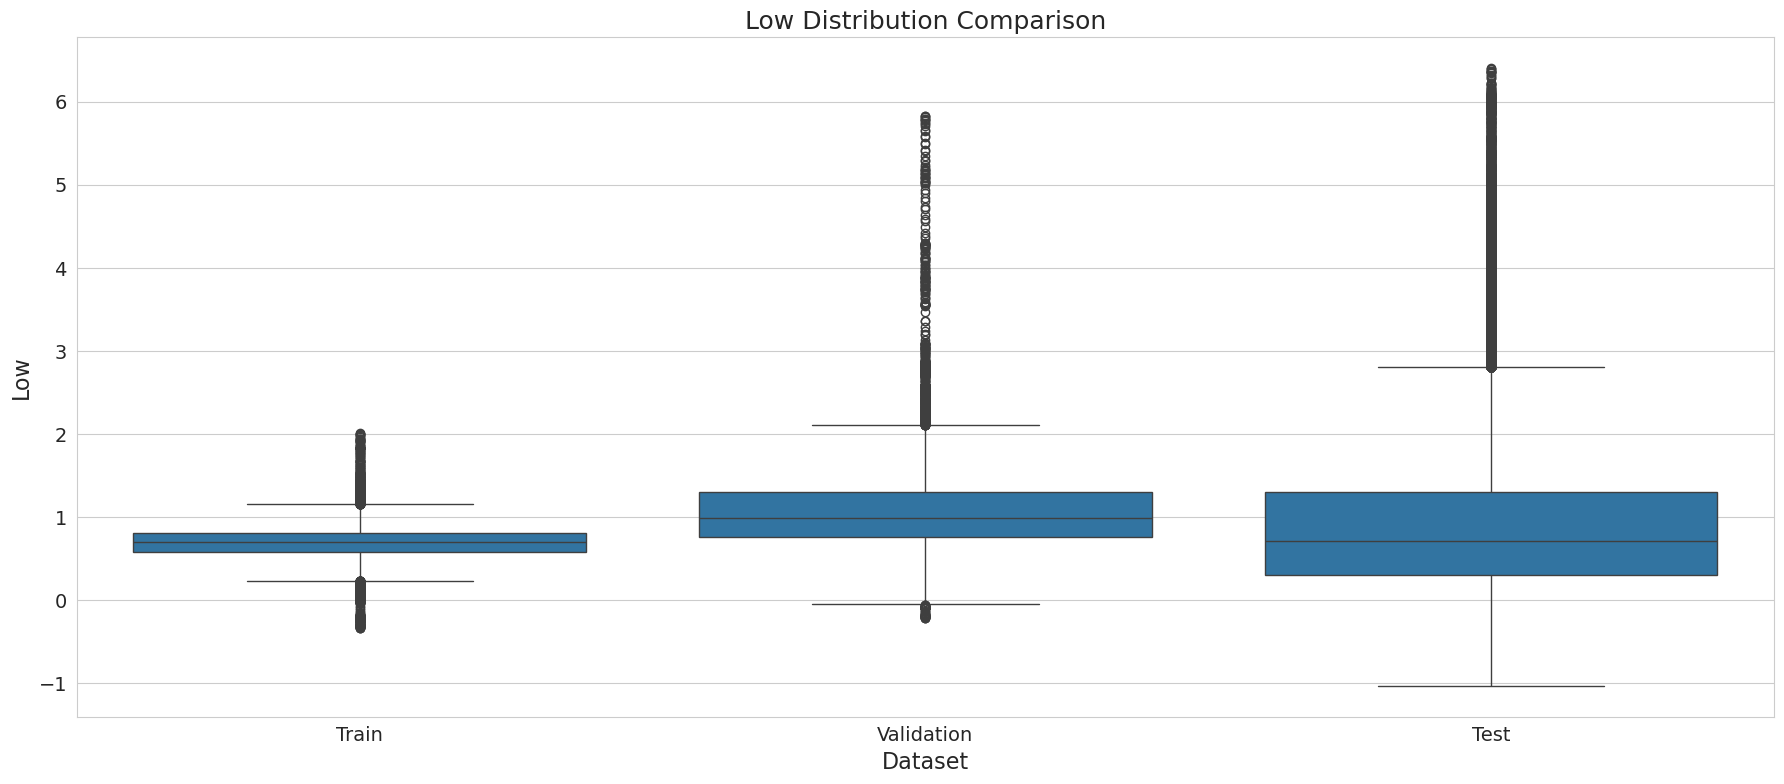

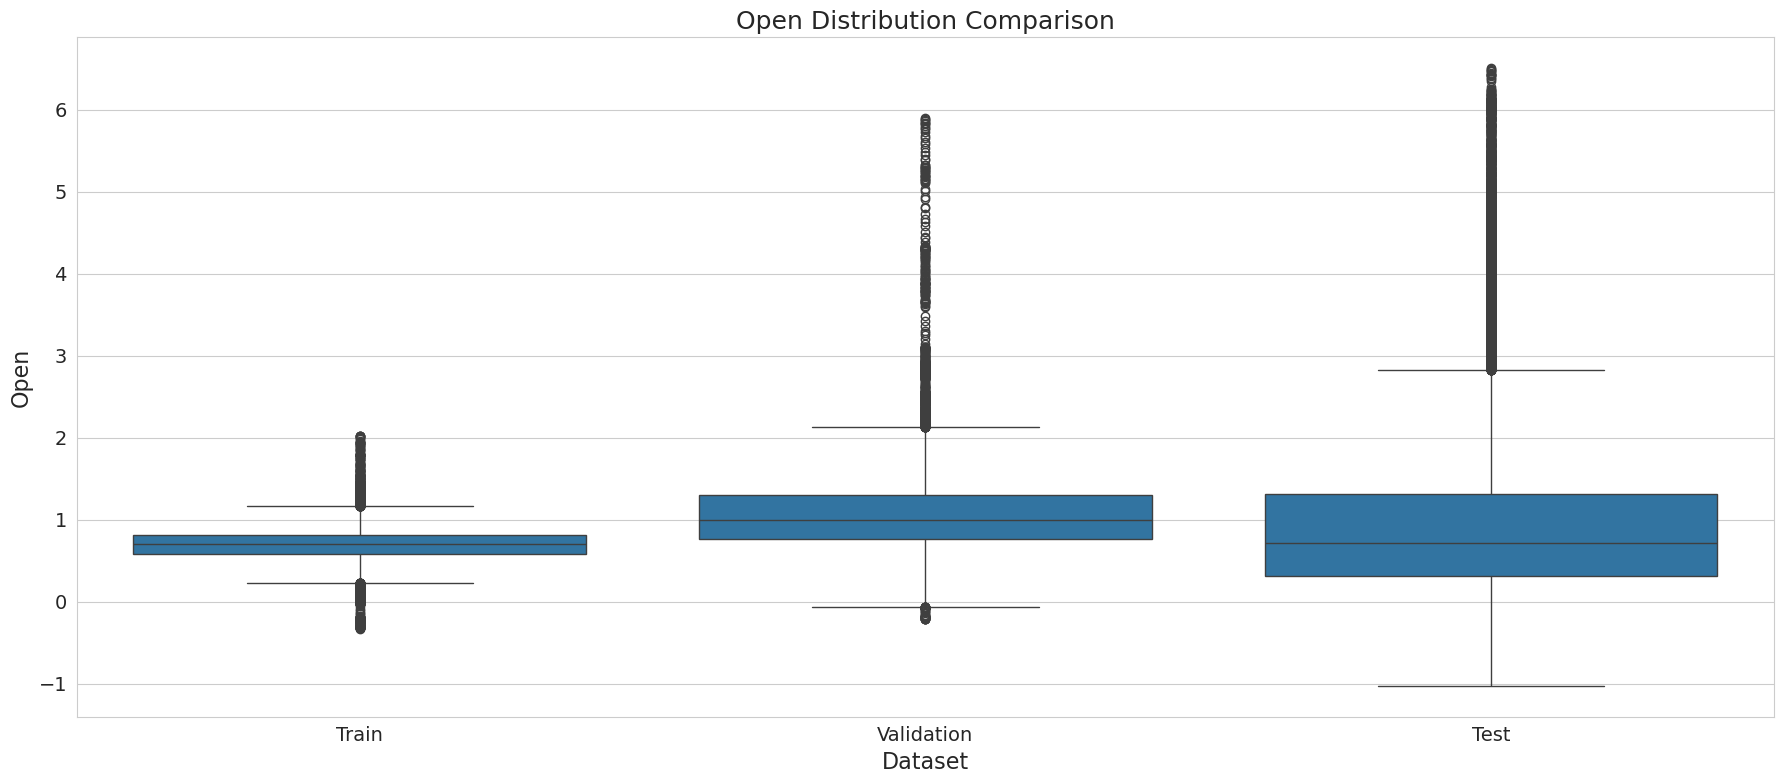

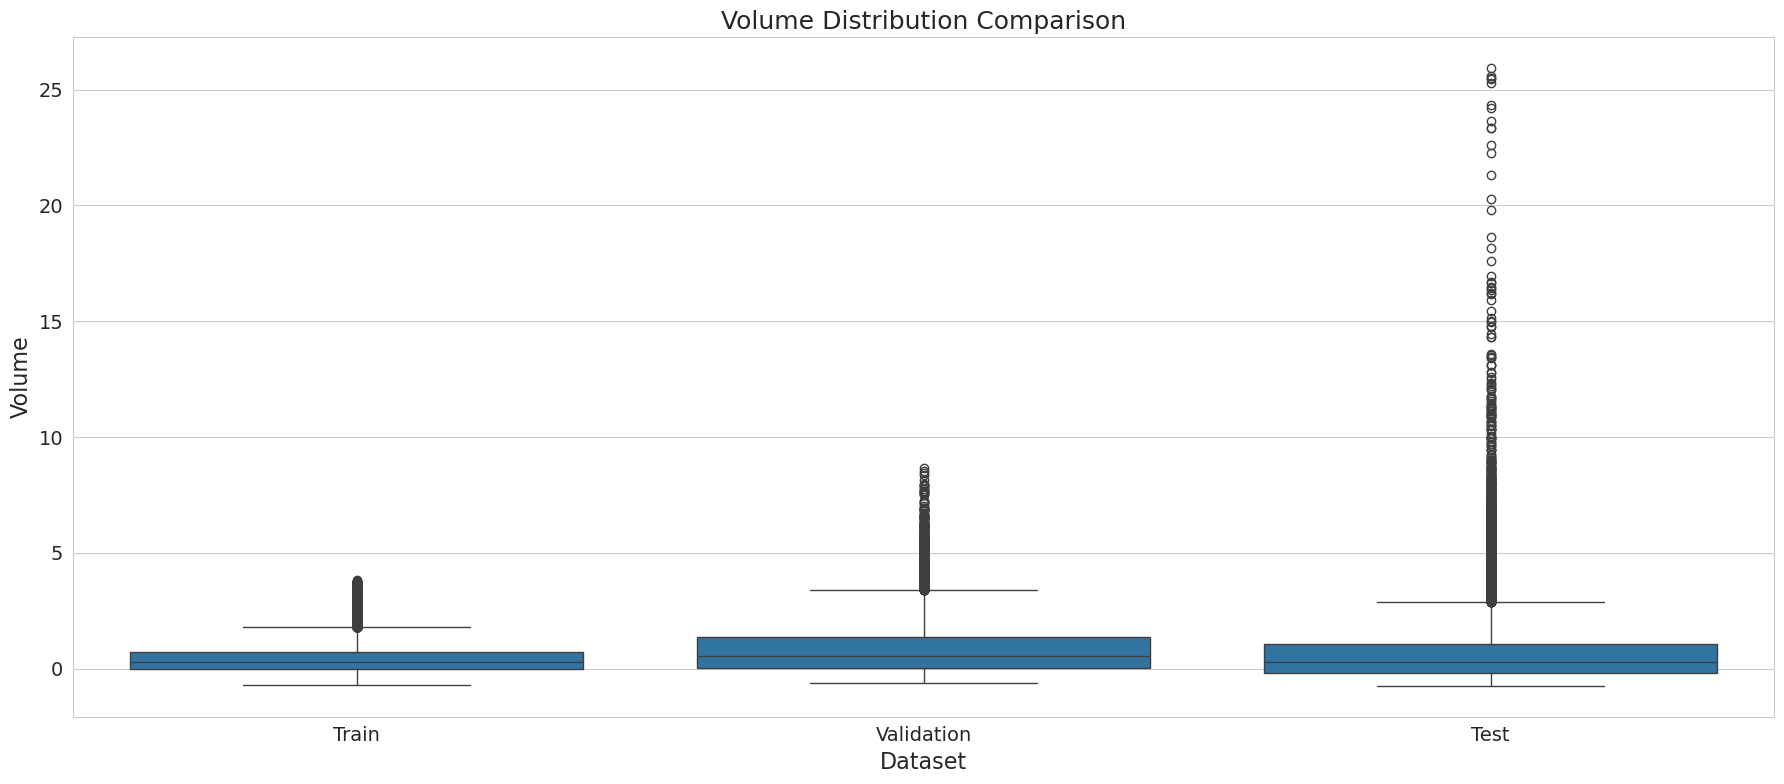


5. Time Series Analysis


<Figure size 2000x1000 with 0 Axes>

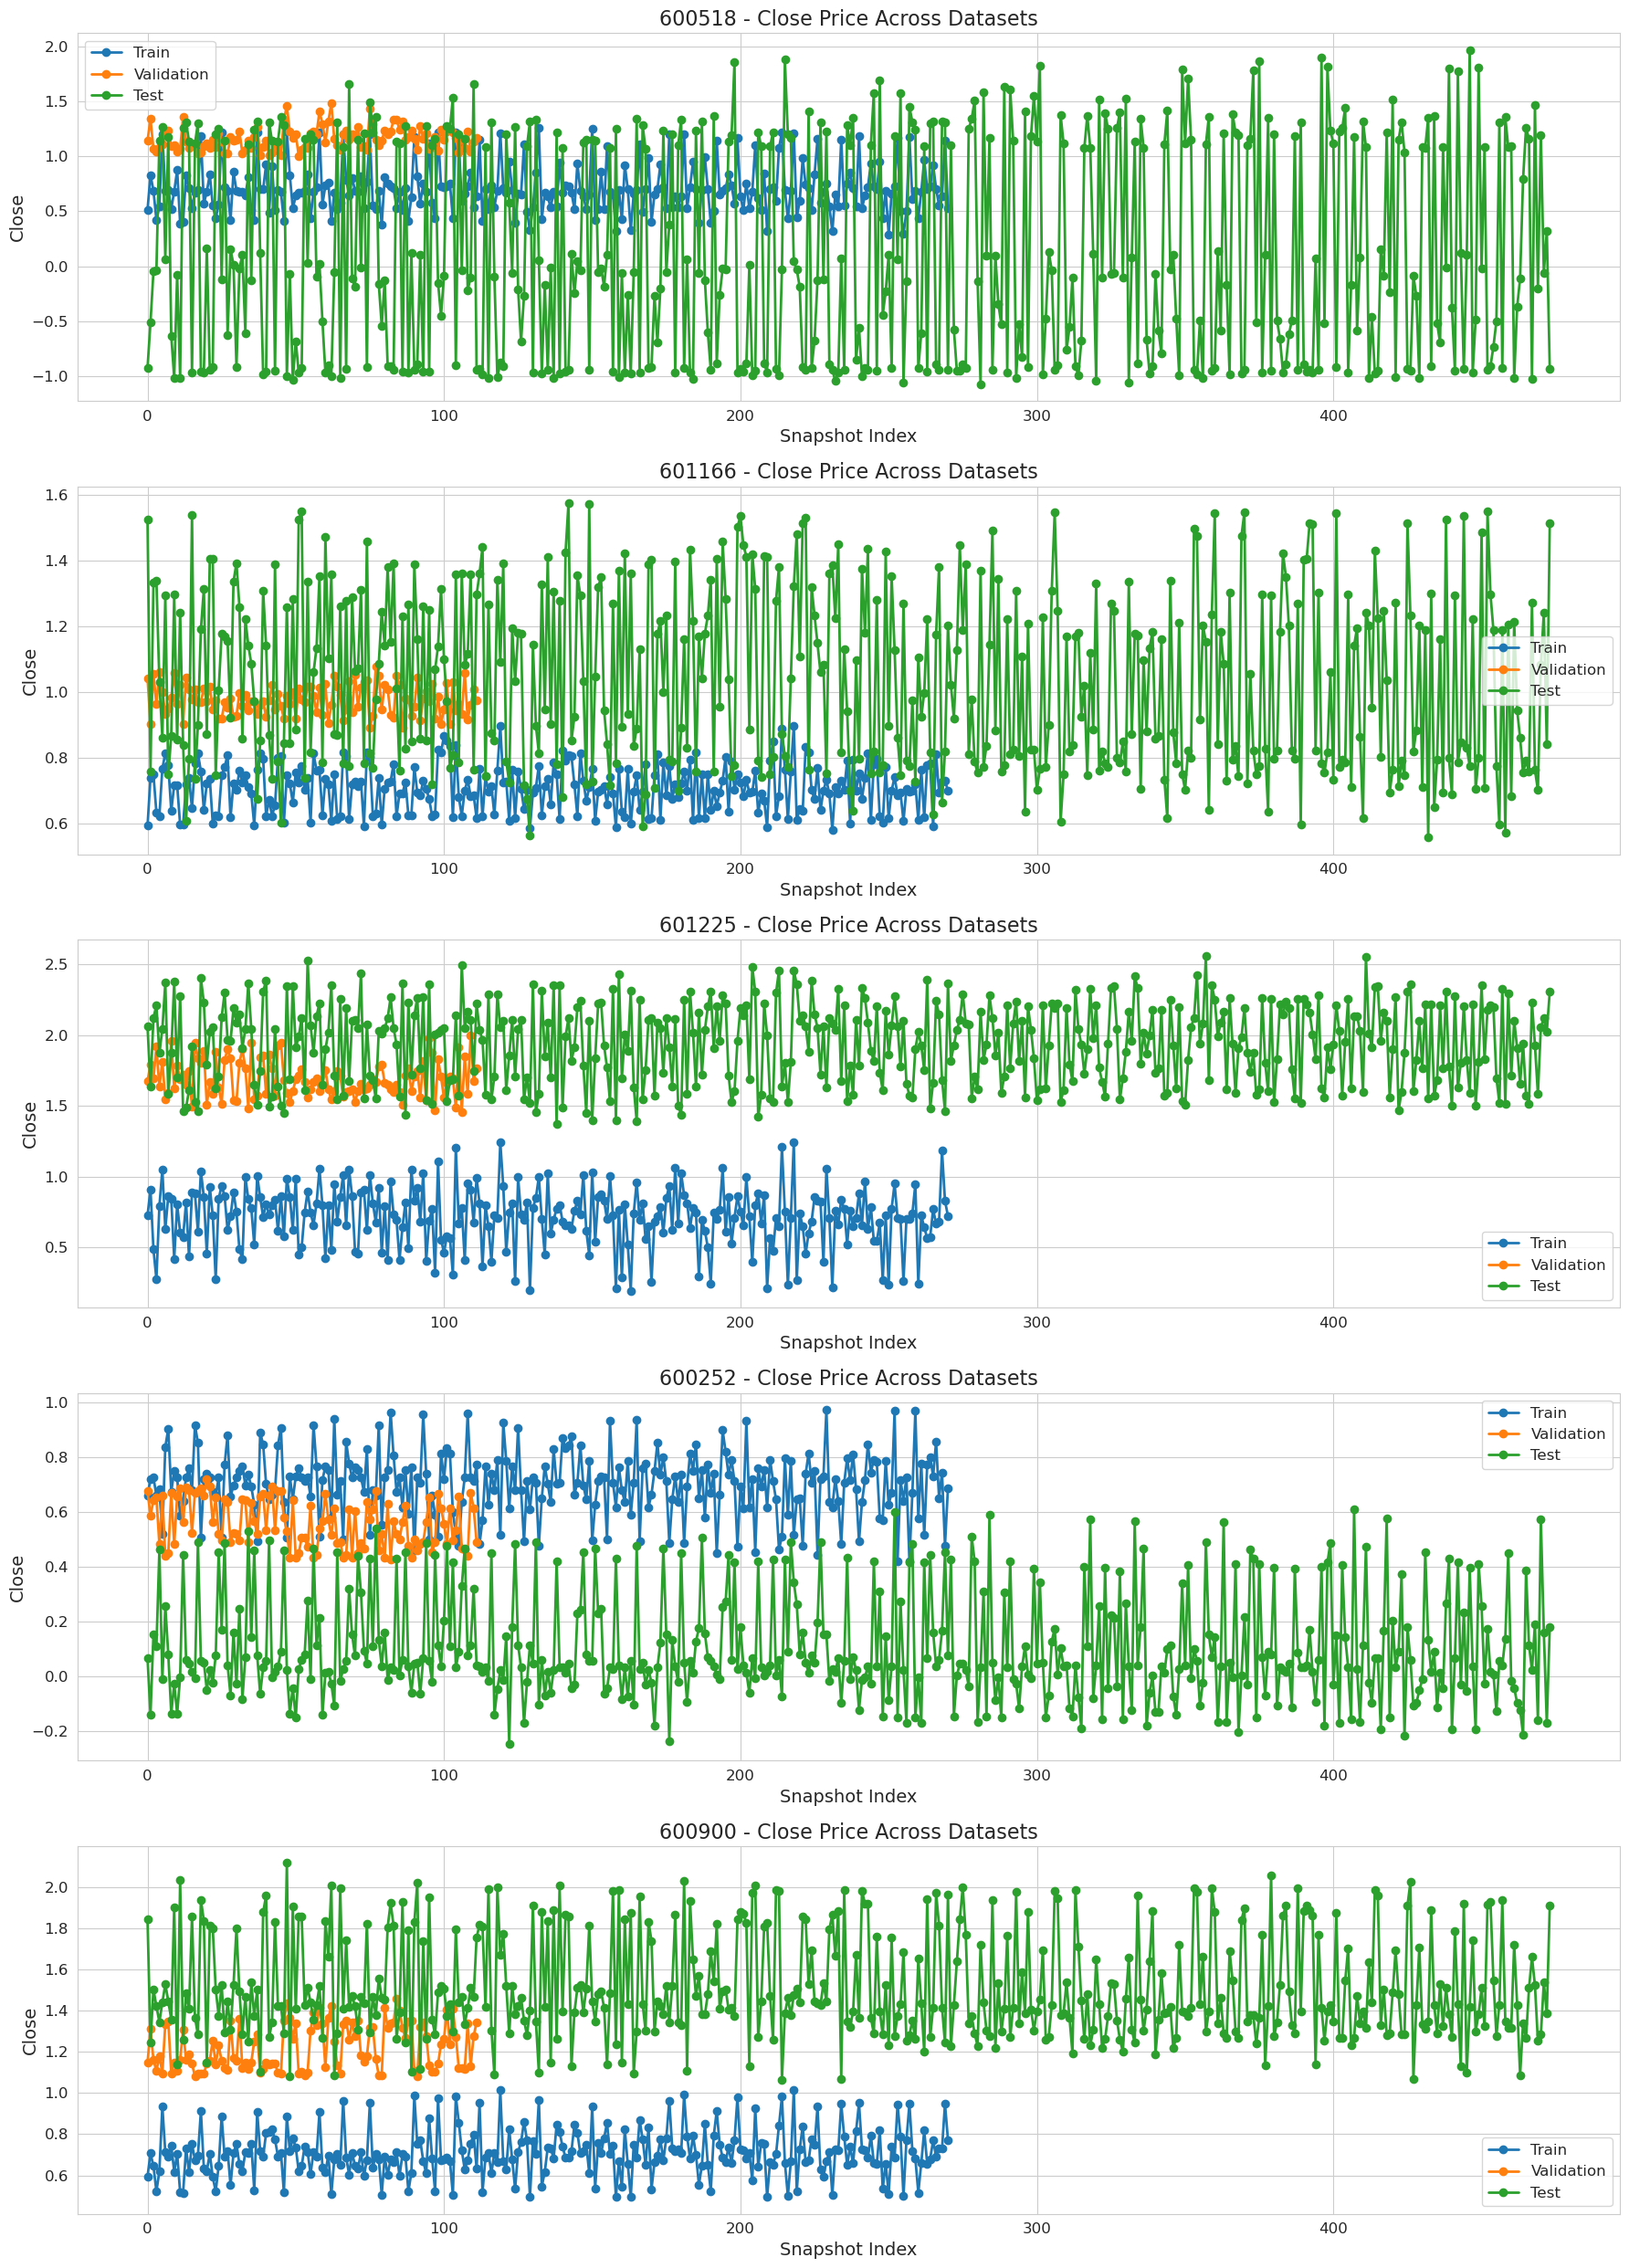


6. Network Structure Visualization
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)


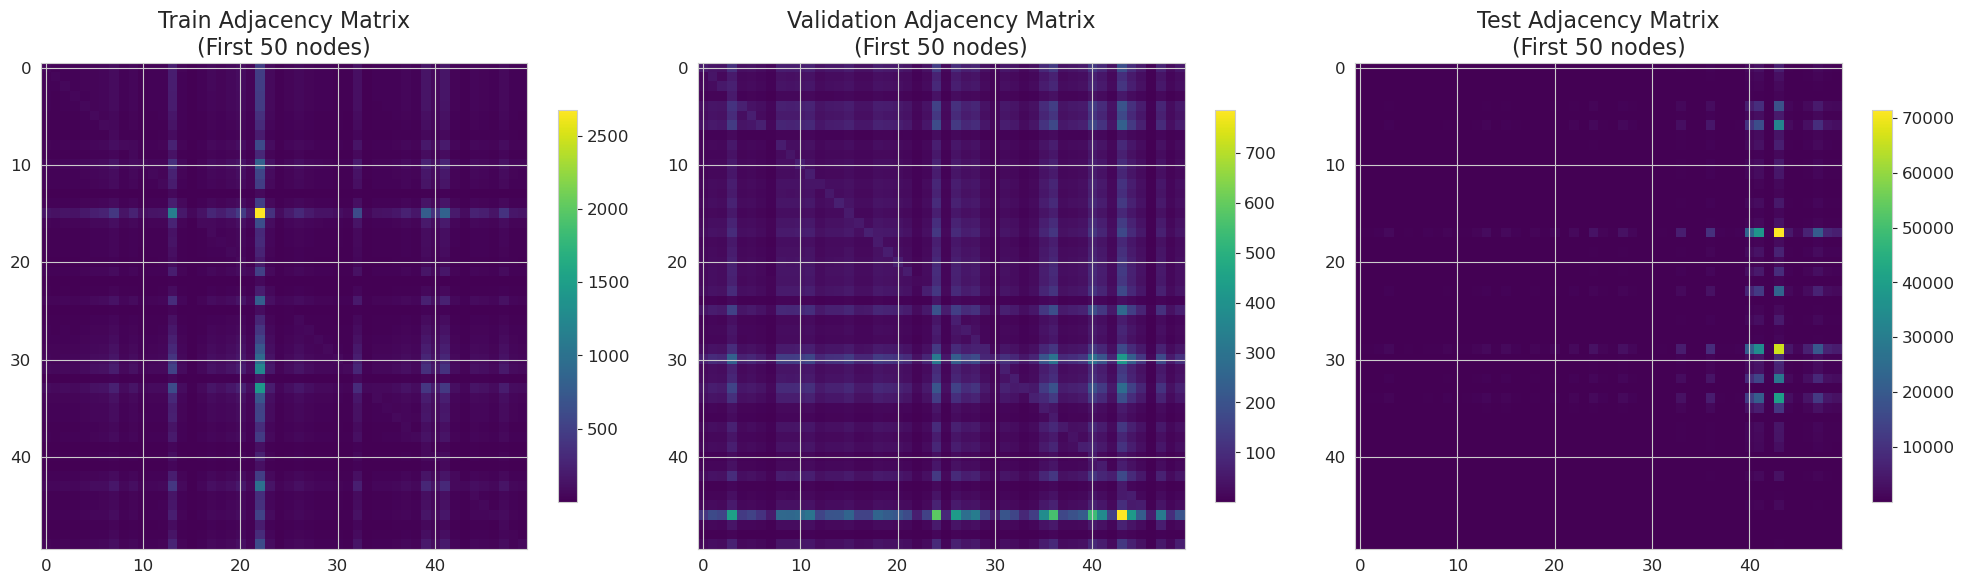


7. Derived Features Analysis


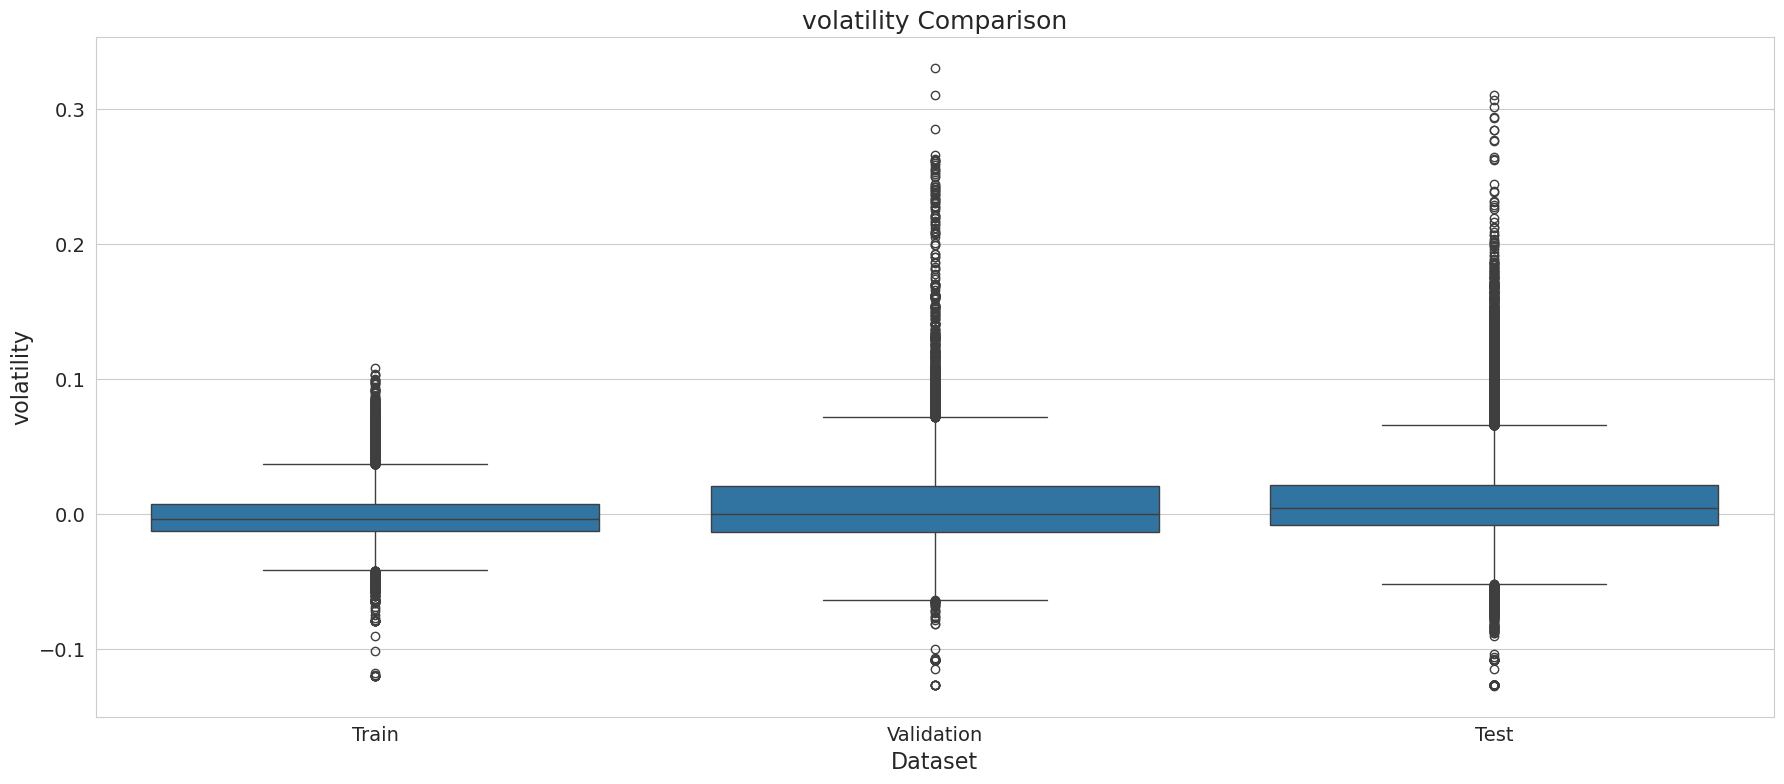

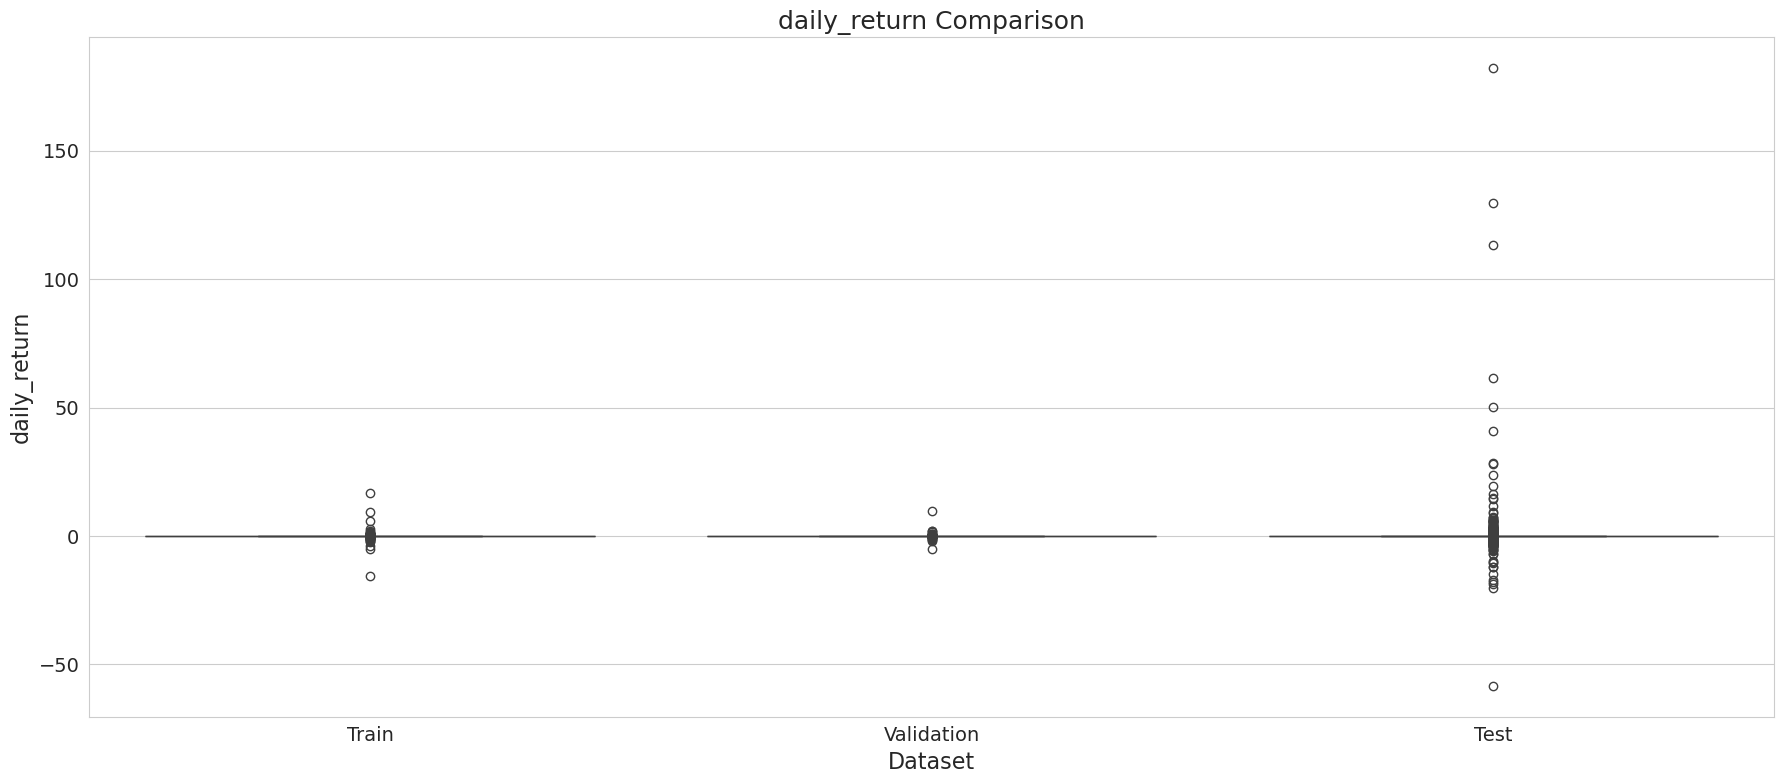

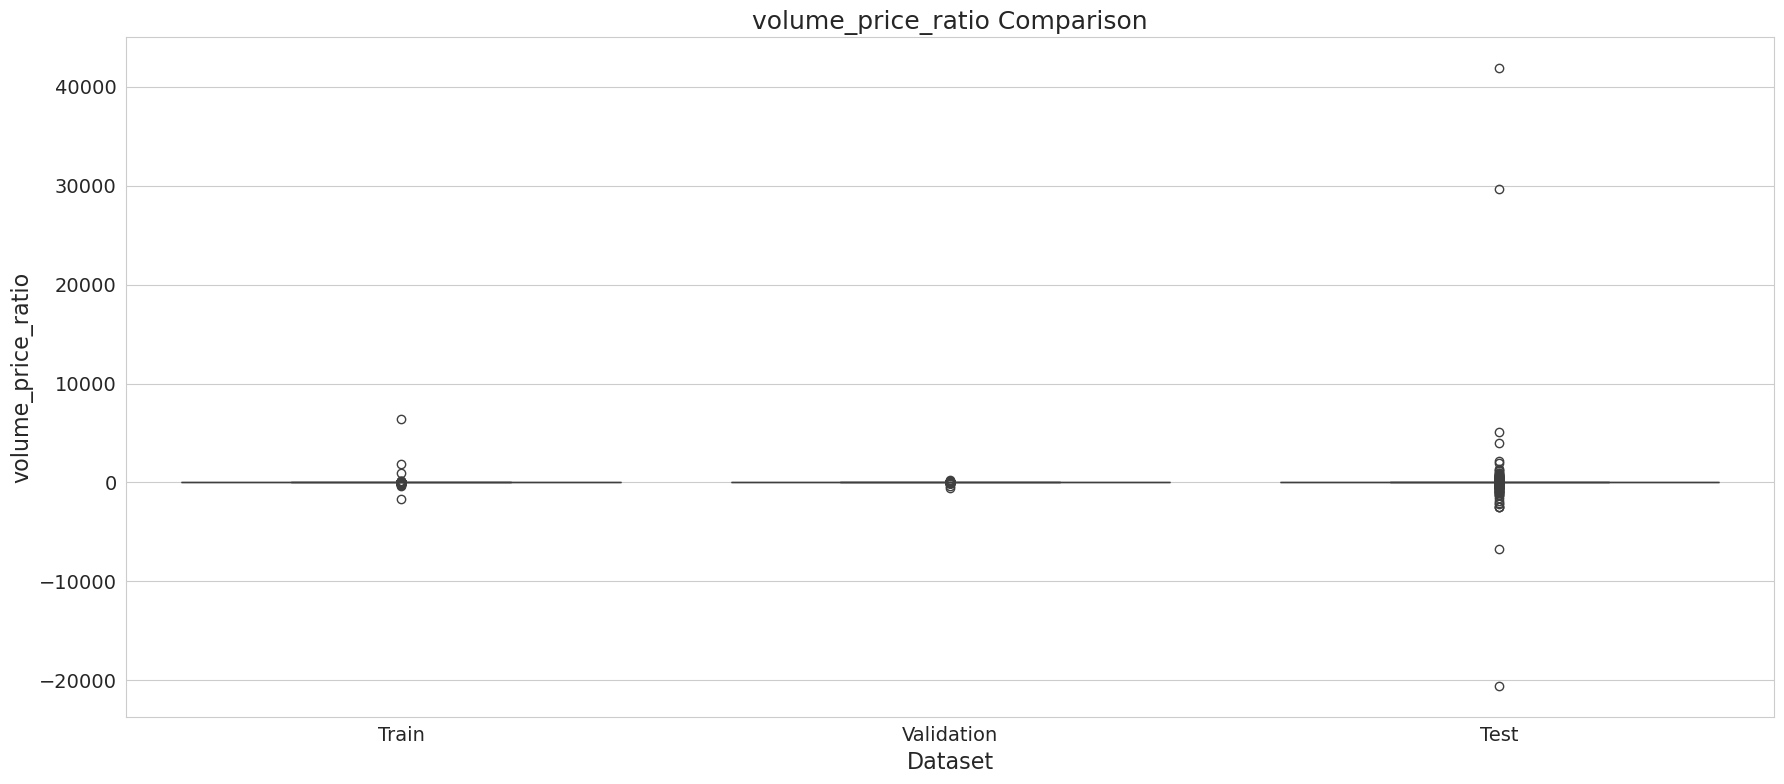

In [90]:
# Inter-Market Analysis of Train, Validation, and Test Sets
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec

# Set larger figure sizes for better readability
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Create a function to compare dataset statistics
def compare_dataset_stats(analyzers, names):
    """Compare basic statistics of multiple datasets"""
    stats = []
    for i, analyzer in enumerate(analyzers):
        stats.append({
            'Dataset': names[i],
            'Market': analyzer.market_name,
            'Time Period': f"{analyzer.start_date}-{analyzer.end_date}",
            'Num Nodes': analyzer.num_nodes,
            'Num Snapshots': analyzer.num_snapshots,
            'Window Size': analyzer.window_size,
            'Normalizer': analyzer.normalizer
        })
    return pd.DataFrame(stats)

# Create function for degree distribution analysis
def plot_degree_distributions(analyzers, names):
    """Plot degree distributions for multiple datasets"""
    plt.figure(figsize=(18, 10))
    for i, analyzer in enumerate(analyzers):
        degrees = analyzer.get_degree_dist()
        sns.kdeplot(degrees, label=names[i], fill=True, alpha=0.3)
    
    plt.title('Degree Distribution Comparison', fontsize=18)
    plt.xlabel('Node Degree', fontsize=16)
    plt.ylabel('Density', fontsize=16)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

# Function to compare snapshot statistics
def compare_snapshot_stats(analyzers, names):
    """Compare snapshot statistics across datasets"""
    fig, axs = plt.subplots(2, 2, figsize=(20, 16))
    
    for i, analyzer in enumerate(analyzers):
        snapshot_info = analyzer.get_snapshots_info_df()
        
        # Up-Down ratio plot
        axs[0, 0].plot(snapshot_info['snapshot_index'], snapshot_info['up_ratio'], 
                        label=f"{names[i]} (Up Ratio)", marker='o', markersize=8)
        
        # Connectivity plot
        axs[0, 1].plot(snapshot_info['snapshot_index'], snapshot_info['connectivity'], 
                       label=f"{names[i]}", marker='s', markersize=8)
        
        # Number of edges
        axs[1, 0].plot(snapshot_info['snapshot_index'], snapshot_info['num_edges'], 
                       label=f"{names[i]}", marker='^', markersize=8)
        
        # Calculate homophily for each snapshot
        homophily_scores = [analyzer.get_homophily_score(idx) for idx in range(analyzer.num_snapshots)]
        axs[1, 1].plot(range(len(homophily_scores)), homophily_scores, 
                       label=f"{names[i]}", marker='*', markersize=8)
    
    # Set titles and labels
    axs[0, 0].set_title('Up Ratio Over Time', fontsize=16)
    axs[0, 0].set_xlabel('Snapshot Index', fontsize=14)
    axs[0, 0].set_ylabel('Up Ratio', fontsize=14)
    
    axs[0, 1].set_title('Network Connectivity', fontsize=16)
    axs[0, 1].set_xlabel('Snapshot Index', fontsize=14)
    axs[0, 1].set_ylabel('Connectivity', fontsize=14)
    
    axs[1, 0].set_title('Number of Edges', fontsize=16)
    axs[1, 0].set_xlabel('Snapshot Index', fontsize=14)
    axs[1, 0].set_ylabel('Edge Count', fontsize=14)
    
    axs[1, 1].set_title('Homophily Score', fontsize=16)
    axs[1, 1].set_xlabel('Snapshot Index', fontsize=14)
    axs[1, 1].set_ylabel('Homophily', fontsize=14)
    
    for ax in axs.flatten():
        ax.legend(fontsize=12)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

# Function to compare feature distributions
def compare_feature_distributions(analyzers, names):
    """Compare distributions of features across datasets"""
    feature_dfs = []
    for i, analyzer in enumerate(analyzers):
        df = analyzer.analyze_node_features()
        df['dataset'] = names[i]
        feature_dfs.append(df)
    
    all_features = pd.concat(feature_dfs)
    
    for feature in analyzers[0].features:
        plt.figure(figsize=(18, 8))
        sns.boxplot(x='dataset', y=feature, data=all_features)
        plt.title(f'{feature} Distribution Comparison', fontsize=18)
        plt.xlabel('Dataset', fontsize=16)
        plt.ylabel(feature, fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.tight_layout()
        plt.show()

# Function to analyze time series data
def compare_time_series(analyzers, names, feature='Close'):
    """Compare time series data for specific stocks across datasets"""
    plt.figure(figsize=(20, 10))
    
    # Select common stocks across all datasets
    common_stocks = set(analyzers[0].index_to_stock.values())
    for analyzer in analyzers[1:]:
        common_stocks = common_stocks.intersection(set(analyzer.index_to_stock.values()))
    
    # Take a sample of stocks if there are too many
    sample_size = min(5, len(common_stocks))
    sample_stocks = list(common_stocks)[:sample_size]
    
    # Create subplots for each stock
    fig, axes = plt.subplots(sample_size, 1, figsize=(18, 5*sample_size))
    if sample_size == 1:
        axes = [axes]  # Make sure axes is iterable
    
    for i, stock in enumerate(sample_stocks):
        for j, analyzer in enumerate(analyzers):
            ts_data = analyzer.get_feature_timeseries(stock_ticker=stock, feature=feature)
            axes[i].plot(ts_data['snapshot'], ts_data['value'], label=names[j], marker='o', linewidth=2)
        
        axes[i].set_title(f'{stock} - {feature} Price Across Datasets', fontsize=16)
        axes[i].set_xlabel('Snapshot Index', fontsize=14)
        axes[i].set_ylabel(feature, fontsize=14)
        axes[i].legend(fontsize=12)
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()

# Function to analyze network adjacency heatmaps
def compare_adjacency_heatmaps(analyzers, names):
    """Compare adjacency matrices for the first snapshot of each dataset"""
    fig, axes = plt.subplots(1, len(analyzers), figsize=(20, 6))
    
    for i, analyzer in enumerate(analyzers):
        adj_matrix = analyzer.get_snapshots_adjacency_matrix([0])[0]  # Get first snapshot
        # If too large, show just a subset
        max_nodes = min(50, adj_matrix.shape[0])
        im = axes[i].imshow(adj_matrix[:max_nodes, :max_nodes], cmap='viridis')
        axes[i].set_title(f'{names[i]} Adjacency Matrix\n(First {max_nodes} nodes)', fontsize=16)
        fig.colorbar(im, ax=axes[i], shrink=0.7)
    
    plt.tight_layout()
    plt.show()

# Function to analyze derived features
def compare_derived_features(analyzers, names):
    """Compare derived features across datasets"""
    derived_dfs = []
    for i, analyzer in enumerate(analyzers):
        df = analyzer.calculate_derived_features()
        df['dataset'] = names[i]
        derived_dfs.append(df)
    
    all_derived = pd.concat(derived_dfs)
    
    # Check which derived features are available
    derived_features = [col for col in all_derived.columns 
                       if col not in analyzers[0].features + ['ticker', 'snapshot_idx', 'dataset']]
    
    if derived_features:
        for feature in derived_features:
            plt.figure(figsize=(18, 8))
            sns.boxplot(x='dataset', y=feature, data=all_derived)
            plt.title(f'{feature} Comparison', fontsize=18)
            plt.xlabel('Dataset', fontsize=16)
            plt.ylabel(feature, fontsize=16)
            plt.xticks(fontsize=14)
            plt.yticks(fontsize=14)
            plt.tight_layout()
            plt.show()

# Run the analysis
analyzers = [train_analyzer, val_analyzer, test_analyzer]
names = ['Train', 'Validation', 'Test']

print("1. Dataset Statistics Comparison")
display(compare_dataset_stats(analyzers, names))

print("\n2. Degree Distribution Analysis")
plot_degree_distributions(analyzers, names)

print("\n3. Snapshot Statistics Comparison")
compare_snapshot_stats(analyzers, names)

print("\n4. Feature Distributions Comparison")
compare_feature_distributions(analyzers, names)

print("\n5. Time Series Analysis")
compare_time_series(analyzers, names, feature='Close')

print("\n6. Network Structure Visualization")
compare_adjacency_heatmaps(analyzers, names)

print("\n7. Derived Features Analysis")
compare_derived_features(analyzers, names)